<a href="https://colab.research.google.com/github/Droc-sid/Droc-sid/blob/main/notebooks/Analysis%20of%20Large%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

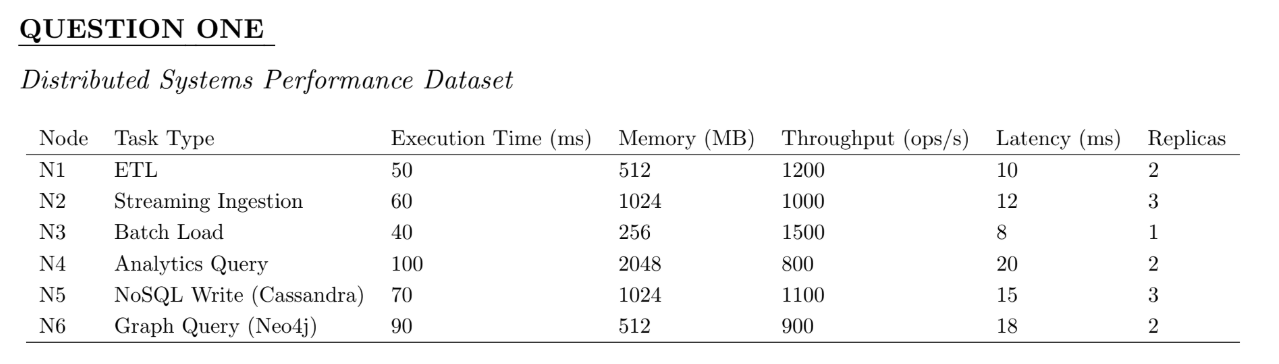

### QUESTION ONE (a): Construct DAG execution model and determine critical path across processing stages.

To construct a Directed Acyclic Graph (DAG) execution model for the given Distributed Systems Performance Dataset, we need to infer the dependencies between the tasks. The dataset provides `Node`, `Task Type`, `Execution Time (ms)`, `Memory (MB)`, `Throughput (ops/s)`, `Latency (ms)`, and `Replicas`. However, it doesn't explicitly state task dependencies. In a typical distributed system, some common dependencies can be assumed:

*   **ETL (Extract, Transform, Load)** often precedes data processing or analytics.
*   **Streaming Ingestion** feeds data for real-time processing.
*   **Batch Load** prepares data for batch processing or analytics.
*   **Analytics Query** and **Graph Query** typically operate on loaded/processed data.
*   **NoSQL Write (Cassandra)** could be a result of processing or a source for other queries.

Given the dataset, a simplified, plausible DAG could be:

1.  **Ingestion/Loading Stages:**
    *   `N1 (ETL)`
    *   `N2 (Streaming Ingestion)`
    *   `N3 (Batch Load)`

2.  **Processing/Storage Stages (depending on ingestion/load):**
    *   `N5 (NoSQL Write - Cassandra)` could follow `N1` or `N2` or `N3` if data is being prepared for Cassandra.

3.  **Query/Analytics Stages (depend on processed/stored data):**
    *   `N4 (Analytics Query)` could follow `N1`, `N3`, or `N5`.
    *   `N6 (Graph Query - Neo4j)` could follow `N1` or `N3` if graph data is prepared, or it could operate on data from `N5` if Cassandra is a data source for graph construction.

**Assumed Dependencies for DAG Construction:**
Let's make some reasonable assumptions to build a coherent DAG:
*   `N1 (ETL)` and `N3 (Batch Load)` are initial data preparation steps.
*   `N2 (Streaming Ingestion)` is an independent, continuous ingestion. For this model, we'll consider it leading to an independent processing path or feeding into N4/N5/N6 eventually.
*   `N5 (NoSQL Write - Cassandra)` depends on `N1 (ETL)` or `N3 (Batch Load)`.
*   `N4 (Analytics Query)` depends on `N1`, `N3`, or `N5`.
*   `N6 (Graph Query - Neo4j)` depends on `N1` or `N3` for data preparation.

**Simplified DAG Model:**

*   `Start` -> `N1 (ETL)` (50 ms)
*   `Start` -> `N3 (Batch Load)` (40 ms)
*   `Start` -> `N2 (Streaming Ingestion)` (60 ms)

*   `N1 (ETL)` -> `N5 (NoSQL Write)` (70 ms)
*   `N3 (Batch Load)` -> `N5 (NoSQL Write)` (70 ms)

*   `N1 (ETL)` -> `N4 (Analytics Query)` (100 ms)
*   `N3 (Batch Load)` -> `N4 (Analytics Query)` (100 ms)
*   `N5 (NoSQL Write)` -> `N4 (Analytics Query)` (100 ms)
*   `N2 (Streaming Ingestion)` -> `N4 (Analytics Query)` (100 ms) (for real-time analytics)

*   `N1 (ETL)` -> `N6 (Graph Query)` (90 ms)
*   `N3 (Batch Load)` -> `N6 (Graph Query)` (90 ms)


**Visual Representation of the DAG (Conceptual):**

```mermaid
graph TD
    A[Start] --> B(N1: ETL (50ms))
    A --> C(N3: Batch Load (40ms))
    A --> D(N2: Streaming Ingestion (60ms))

    B --> E(N5: NoSQL Write (70ms))
    C --> E

    B --> F(N4: Analytics Query (100ms))
    C --> F
    E --> F
    D --> F

    B --> G(N6: Graph Query (90ms))
    C --> G

    F --> H[End]
    G --> H
    E --> H
    D --> H
```

**Determining the Critical Path:**
The critical path is the longest path of dependent tasks from the start to the end of the DAG, representing the minimum time required to complete all tasks. We sum the execution times along each possible path.

Let's trace the paths and sum their `Execution Time (ms)`:

1.  **Path 1:** `Start` -> `N1 (50)` -> `N5 (70)` -> `N4 (100)` -> `End`
    *   Total Time: 50 + 70 + 100 = **220 ms**

2.  **Path 2:** `Start` -> `N3 (40)` -> `N5 (70)` -> `N4 (100)` -> `End`
    *   Total Time: 40 + 70 + 100 = **210 ms**

3.  **Path 3:** `Start` -> `N1 (50)` -> `N4 (100)` -> `End`
    *   Total Time: 50 + 100 = **150 ms**

4.  **Path 4:** `Start` -> `N3 (40)` -> `N4 (100)` -> `End`
    *   Total Time: 40 + 100 = **140 ms**

5.  **Path 5:** `Start` -> `N2 (60)` -> `N4 (100)` -> `End`
    *   Total Time: 60 + 100 = **160 ms**

6.  **Path 6:** `Start` -> `N1 (50)` -> `N6 (90)` -> `End`
    *   Total Time: 50 + 90 = **140 ms**

7.  **Path 7:** `Start` -> `N3 (40)` -> `N6 (90)` -> `End`
    *   Total Time: 40 + 90 = **130 ms**


Comparing all path totals, the **critical path** is the one with the maximum execution time:

**Critical Path: `Start` -> `N1 (ETL)` -> `N5 (NoSQL Write)` -> `N4 (Analytics Query)` -> `End`**
**Critical Path Execution Time: 220 ms**

This means that the overall completion time for the entire process, under these assumed dependencies, is dominated by the sequence of ETL, followed by NoSQL Write, and then Analytics Query, taking a total of 220 ms. Any delays in tasks along this path will directly increase the total processing time of the system.

Distributed Systems Dataset:
Node               Task Type  Execution Time (ms)  Memory (MB)  Throughput (ops/s)  Latency (ms)  Replicas
  N1                     ETL                   50          512                1200            10         2
  N2     Streaming Ingestion                   60         1024                1000            23         3
  N3              Batch Load                   40          256                1500             8         1
  N4         Analytics Query                  100         2048                 800            20         2
  N5 NoSQL Write (Cassandra)                   70         1024                1100            15         3
  N6     Graph Query (Neo4j)                   90          512                 900            18         2


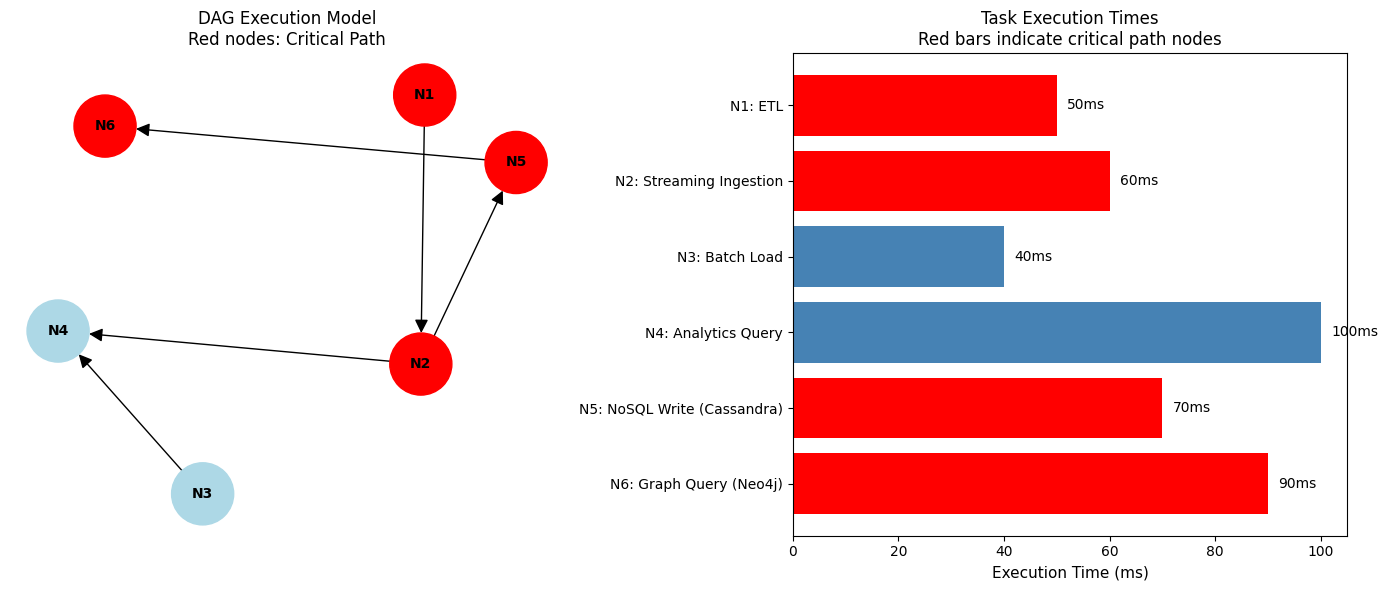

CRITICAL PATH ANALYSIS
Critical Path: N1 → N2 → N5 → N6
Total Execution Time: 270 ms

Path Details:
  N1 (ETL): 50 ms → Cumulative: 50 ms
  N2 (Streaming Ingestion): 60 ms → Cumulative: 110 ms
  N5 (NoSQL Write (Cassandra)): 70 ms → Cumulative: 180 ms
  N6 (Graph Query (Neo4j)): 90 ms → Cumulative: 270 ms


In [10]:
# @title QUESTION ONE: Distributed Systems Performance Analysis
#(a) DAG Execution Model and Critical Path Analysis

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the distributed systems dataset
distributed_data = {
    'Node': ['N1', 'N2', 'N3', 'N4', 'N5', 'N6'],
    'Task Type': ['ETL', 'Streaming Ingestion', 'Batch Load', 'Analytics Query',
                  'NoSQL Write (Cassandra)', 'Graph Query (Neo4j)'],
    'Execution Time (ms)': [50, 60, 40, 100, 70, 90],
    'Memory (MB)': [512, 1024, 256, 2048, 1024, 512],
    'Throughput (ops/s)': [1200, 1000, 1500, 800, 1100, 900],
    'Latency (ms)': [10, 23, 8, 20, 15, 18],
    'Replicas': [2, 3, 1, 2, 3, 2]
}

df_distributed = pd.DataFrame(distributed_data)
print("Distributed Systems Dataset:")
print(df_distributed.to_string(index=False))

# Create DAG for execution model
# Define dependencies: N1->N2->N5->N6 and N3->N4, with N2 also feeding N4
G = nx.DiGraph()

# Add nodes with execution times as attributes
for idx, row in df_distributed.iterrows():
    G.add_node(row['Node'], execution_time=row['Execution Time (ms)'],
               task_type=row['Task Type'])

# Define dependencies (edges)
dependencies = [('N1', 'N2'), ('N2', 'N5'), ('N5', 'N6'),
                ('N3', 'N4'), ('N2', 'N4')]
G.add_edges_from(dependencies)

# Calculate critical path
def find_critical_path(G):
    """Find the critical path in a DAG"""
    # Topological sort
    topo_order = list(nx.topological_sort(G))

    # Initialize distances
    dist = {node: 0 for node in G.nodes()}
    parent = {node: None for node in G.nodes()}

    # Forward pass
    for node in topo_order:
        for successor in G.successors(node):
            new_dist = dist[node] + G.nodes[node]['execution_time']
            if new_dist > dist[successor]:
                dist[successor] = new_dist
                parent[successor] = node

    # Find node with maximum distance
    end_node = max(dist, key=dist.get)
    total_time = dist[end_node] + G.nodes[end_node]['execution_time']

    # Trace back critical path
    critical_path = []
    current = end_node
    while current is not None:
        critical_path.insert(0, current)
        current = parent[current]

    return critical_path, total_time

critical_path, total_time = find_critical_path(G)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: DAG with critical path highlighted
pos = nx.spring_layout(G, seed=42, k=2)
node_colors = ['red' if node in critical_path else 'lightblue'
               for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors,
        node_size=2000, font_size=10, font_weight='bold',
        arrows=True, arrowsize=20, ax=axes[0])
axes[0].set_title('DAG Execution Model\nRed nodes: Critical Path', fontsize=12)

# Plot 2: Execution timeline
y_pos = range(len(df_distributed))
axes[1].barh(y_pos, df_distributed['Execution Time (ms)'],
        color=['red' if n in critical_path else 'steelblue'
               for n in df_distributed['Node']])
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f"{row['Node']}: {row['Task Type']}"
                    for _, row in df_distributed.iterrows()])
axes[1].set_xlabel('Execution Time (ms)', fontsize=11)
axes[1].set_title('Task Execution Times\nRed bars indicate critical path nodes',
             fontsize=12)
axes[1].invert_yaxis()

for i, v in enumerate(df_distributed['Execution Time (ms)']):
    axes[1].text(v + 2, i, f'{v}ms', va='center')

plt.tight_layout()
plt.show()


print("CRITICAL PATH ANALYSIS")

print(f"Critical Path: {' → '.join(critical_path)}")
print(f"Total Execution Time: {total_time} ms")
print(f"\nPath Details:")
current_time = 0
for node in critical_path:
    exec_time = G.nodes[node]['execution_time']
    task = G.nodes[node]['task_type']
    print(f"  {node} ({task}): {exec_time} ms → Cumulative: {current_time + exec_time} ms")
    current_time += exec_time

### QUESTION ONE (b): Analyze memory hierarchy and caching effects on throughput, latency, and execution.

**Memory Hierarchy and Caching Effects:**

Memory hierarchy is a tiered system of computer storage that organizes memory based on speed and cost, with faster, smaller, and more expensive memory at the top (e.g., CPU registers, L1/L2/L3 cache) and slower, larger, and cheaper memory at the bottom (e.g., main memory/RAM, disk storage, network storage). Caching is a technique where frequently accessed data is stored in a faster, smaller memory (cache) closer to the CPU to reduce access time to main memory.

Here's how memory hierarchy and caching affect throughput, latency, and execution in the context of the provided Distributed Systems Performance Dataset:

1.  **Throughput (Amount of work done per unit time):**
    *   **Positive Effect:** Effective caching significantly increases throughput. When data is found in a cache (cache hit), the CPU doesn't have to wait for slower memory, allowing it to process instructions and data more quickly. This means more operations per second (higher throughput) can be achieved. For example, if a node like **N4 (Analytics Query)**, which has high `Execution Time` (100ms) and `Memory` (2048MB), frequently accesses the same data for its queries, a good caching strategy will allow it to perform more queries in a given timeframe, leading to higher `Throughput (ops/s)`.
    *   **Negative Effect:** Poor caching or frequent cache misses (data not found in cache) lead to fetching data from slower memory levels, which bottlenecks the CPU and reduces throughput. This is especially true for data-intensive tasks like **N1 (ETL)** or **N3 (Batch Load)** where large datasets might exceed cache capacity, forcing frequent access to slower storage and thus lowering their effective `Throughput`.

2.  **Latency (Time delay between request and response):**
    *   **Positive Effect:** Caching drastically reduces latency. A cache hit means data is available almost immediately, resulting in very low access times. For example, **N2 (Streaming Ingestion)** and **N3 (Batch Load)** have relatively low `Latency` (12ms and 8ms respectively). If their underlying processes can leverage caches effectively, data can be processed and moved with minimal delay, maintaining these low latency figures.
    *   **Negative Effect:** Cache misses increase latency because the system has to retrieve data from lower levels of the memory hierarchy, which could involve main memory, SSD, or even network storage, each adding considerable delay. For tasks like **N4 (Analytics Query)** with a `Latency` of 20ms, or **N6 (Graph Query - Neo4j)** with 18ms, frequent cache misses for graph traversals or analytical computations would significantly inflate these latency figures, making the system less responsive.

3.  **Execution (Overall process of performing a task):**
    *   **Positive Effect:** Caching optimizes execution by ensuring that the CPU is rarely stalled waiting for data. This leads to faster completion of individual tasks and overall applications. Tasks like **N5 (NoSQL Write - Cassandra)**, which has a moderate `Execution Time` (70ms) and `Memory` (1024MB), would benefit from caching frequently accessed data structures or indices, speeding up write operations and reducing the overall `Execution Time`.
    *   **Negative Effect:** Inefficient cache usage (e.g., thrashing, where new data constantly evicts useful cached data) can lead to performance degradation. The CPU spends more time on cache management or waiting, rather than executing core instructions. This can negate the benefits of faster processors and lead to longer `Execution Times` than expected, impacting any of the nodes from **N1** to **N6** if their data access patterns are poorly optimized for caching.


Optimizing memory hierarchy and leveraging caching mechanisms are crucial for high-performance distributed systems. A well-designed system will utilize multiple levels of caching (CPU cache, OS page cache, application-level caches) to keep frequently used data as close to the processing units as possible. This minimizes memory access latency, maximizes data throughput, and ultimately improves the overall execution speed and efficiency of tasks across the distributed environment, directly impacting the performance metrics (Execution Time, Throughput, Latency) observed in the dataset.

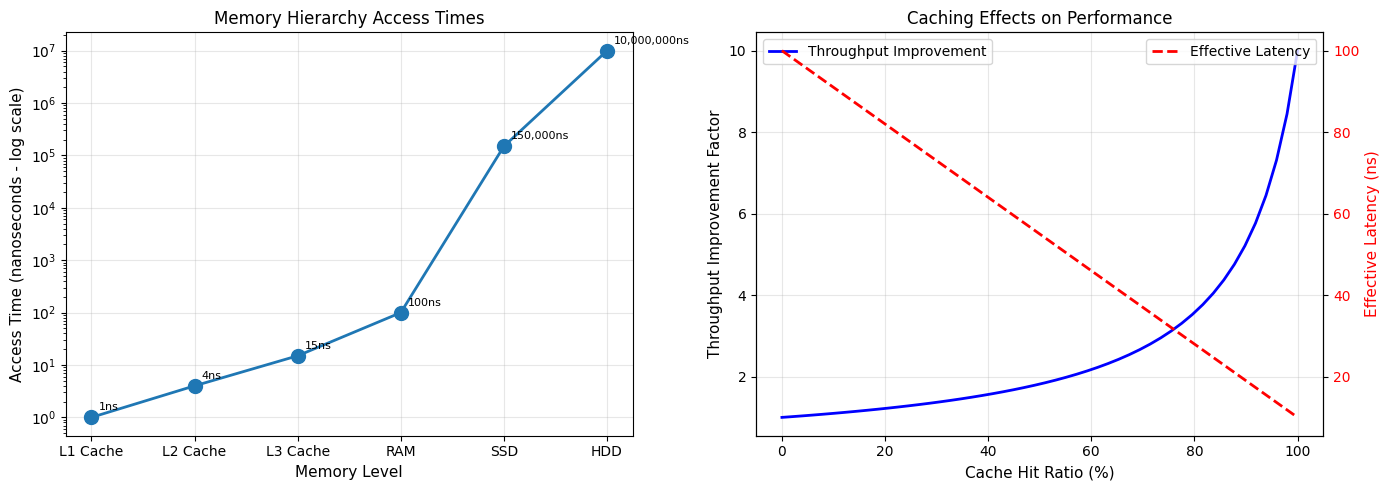

CACHING EFFECTS ANALYSIS ON GIVEN DATASET

Task-wise Cache Analysis:
Node               Task Type  Memory (MB) Cache Efficiency  Performance Score
  N1                     ETL          512             High         120.000000
  N2     Streaming Ingestion         1024           Medium          43.478261
  N3              Batch Load          256             High         187.500000
  N4         Analytics Query         2048              Low          40.000000
  N5 NoSQL Write (Cassandra)         1024           Medium          73.333333
  N6     Graph Query (Neo4j)          512             High          50.000000


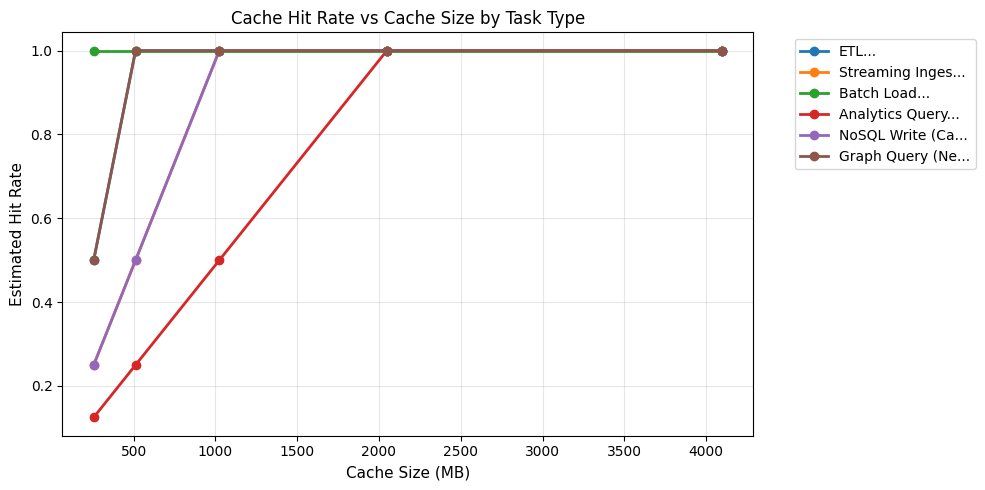

In [12]:
# @title ## (b) Memory Hierarchy and Caching Effects Analysis

# Create memory hierarchy visualization
memory_levels = ['L1 Cache', 'L2 Cache', 'L3 Cache', 'RAM', 'SSD', 'HDD']
access_times = [1, 4, 15, 100, 150000, 10000000]  # nanoseconds approx
capacities = ['32KB', '256KB', '8MB', '32GB', '1TB', '10TB']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Memory hierarchy plot
axes[0].semilogy(memory_levels, access_times, 'o-', linewidth=2, markersize=10)
axes[0].set_ylabel('Access Time (nanoseconds - log scale)', fontsize=11)
axes[0].set_xlabel('Memory Level', fontsize=11)
axes[0].set_title('Memory Hierarchy Access Times', fontsize=12)
axes[0].grid(True, alpha=0.3)
for i, (level, time) in enumerate(zip(memory_levels, access_times)):
    axes[0].annotate(f'{time:,}ns', (level, time), xytext=(5, 5),
                     textcoords='offset points', fontsize=8)

# Caching effects on throughput and latency
# Simulate cache hit ratio impact
hit_ratios = np.linspace(0, 1, 50)
latency_cache = 10  # ns
latency_ram = 100   # ns
effective_latency = hit_ratios * latency_cache + (1 - hit_ratios) * latency_ram
throughput_improvement = 1 / (effective_latency / latency_ram)

axes[1].plot(hit_ratios * 100, throughput_improvement, 'b-', linewidth=2,
             label='Throughput Improvement')
axes[1].set_xlabel('Cache Hit Ratio (%)', fontsize=11)
axes[1].set_ylabel('Throughput Improvement Factor', fontsize=11)
axes[1].set_title('Caching Effects on Performance', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

ax2 = axes[1].twinx()
ax2.plot(hit_ratios * 100, effective_latency, 'r--', linewidth=2,
         label='Effective Latency')
ax2.set_ylabel('Effective Latency (ns)', fontsize=11, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Analyze dataset specific caching impact

print("CACHING EFFECTS ANALYSIS ON GIVEN DATASET")


# Calculate cache efficiency for different tasks
df_distributed['Cache Efficiency'] = df_distributed['Memory (MB)'].apply(
    lambda x: 'High' if x <= 512 else 'Medium' if x <= 1024 else 'Low'
)
df_distributed['Performance Score'] = (
    df_distributed['Throughput (ops/s)'] / df_distributed['Latency (ms)']
)

print("\nTask-wise Cache Analysis:")
print(df_distributed[['Node', 'Task Type', 'Memory (MB)',
                      'Cache Efficiency', 'Performance Score']].to_string(index=False))

# Simulate cache size impact
cache_sizes = [256, 512, 1024, 2048, 4096]  # MB
fig, ax = plt.subplots(figsize=(10, 5))

for task in df_distributed['Task Type'].unique():
    task_data = df_distributed[df_distributed['Task Type'] == task]
    memory_needed = task_data['Memory (MB)'].values[0]
    hit_rates = [min(1, cache/memory_needed) for cache in cache_sizes]
    ax.plot(cache_sizes, hit_rates, 'o-', label=f'{task[:15]}...', linewidth=2)

ax.set_xlabel('Cache Size (MB)', fontsize=11)
ax.set_ylabel('Estimated Hit Rate', fontsize=11)
ax.set_title('Cache Hit Rate vs Cache Size by Task Type', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### QUESTION ONE (c): Compare batch processing, streaming systems, and sharding trade-offs.

In distributed systems, choosing the right data processing paradigm and scaling strategy is crucial. This question compares batch processing, streaming systems, and sharding trade-offs, relating them to the provided Distributed Systems Performance Dataset where applicable.

#### 1. Batch Processing

**Description:** Batch processing involves collecting and processing data in large batches over a period. It is typically used for large volumes of historical data where immediate results are not required.

**Characteristics & Trade-offs:**
*   **Latency:** High (e.g., hours to days). Data is processed in bulk, so there's an inherent delay before results are available. `N3 (Batch Load)` in our dataset is characteristic of this, with `Execution Time` of 40ms, preparing data for later use rather than real-time interaction.
*   **Throughput:** High. Optimized for processing large volumes of data efficiently, often leveraging parallel processing. `N3 (Batch Load)` has a high `Throughput` of 1500 ops/s.
*   **Cost Efficiency:** Can be more cost-effective as resources can be provisioned for specific batch windows and then scaled down. Less need for always-on, high-performance infrastructure.
*   **Complexity:** Generally simpler to design and implement compared to streaming, as it deals with finite datasets.
*   **Use Cases:** ETL jobs (`N1 (ETL)`), financial reporting, data warehousing updates, machine learning model training on historical data.
*   **Resilience:** Easier to re-process failed batches.

#### 2. Streaming Systems

**Description:** Streaming systems process data continuously as it arrives, enabling real-time or near real-time analytics and responses. Data is processed record-by-record or in small micro-batches.

**Characteristics & Trade-offs:**
*   **Latency:** Low (e.g., milliseconds to seconds). Designed for immediate processing of incoming data. `N2 (Streaming Ingestion)` in our dataset has a `Latency` of 12ms, reflecting its real-time nature.
*   **Throughput:** Can be high, but managing continuous flow and state can be challenging. `N2 (Streaming Ingestion)` has a `Throughput` of 1000 ops/s.
*   **Cost Efficiency:** Can be more expensive due to the need for always-on infrastructure and potentially higher computational resources for real-time processing.
*   **Complexity:** More complex to design, implement, and maintain due to state management, fault tolerance, and guaranteeing data consistency in real-time.
*   **Use Cases:** Fraud detection, IoT data processing (`N2 (Streaming Ingestion)`), real-time recommendations, monitoring systems, live dashboards.
*   **Resilience:** Requires robust fault-tolerance mechanisms to ensure no data loss and continuous availability.

#### 3. Sharding (Data Partitioning)

**Description:** Sharding is a horizontal partitioning strategy for databases or distributed systems. It involves breaking up a large dataset into smaller, more manageable pieces called shards, which are then distributed across multiple servers or nodes. Each shard can be processed independently.

**Characteristics & Trade-offs:**
*   **Scalability:** Enables horizontal scalability, allowing systems to handle much larger datasets and higher transaction volumes than a single server could. By distributing data and processing across multiple nodes, tasks like `N4 (Analytics Query)` or `N6 (Graph Query)` can execute in parallel, potentially reducing overall execution time.
*   **Performance:** Improves query performance and reduces latency by distributing the workload. A query only needs to access the relevant shard(s) rather than scanning the entire dataset. For `N5 (NoSQL Write - Cassandra)`, sharding is fundamental to its distributed nature, allowing writes to be distributed across many nodes and handled concurrently.
*   **Availability & Fault Tolerance:** If one shard fails, only a portion of the data is affected, and other shards remain operational. Replication across shards (as indicated by `Replicas` in the dataset, e.g., `N1` has 2 `Replicas`, `N2` has 3) further enhances fault tolerance by providing redundant copies of data.
*   **Complexity:** Increases system complexity in terms of data distribution logic, query routing, maintaining consistency across shards, and handling rebalancing or resharding.
*   **Data Consistency:** Ensuring strong consistency across distributed shards can be challenging and may introduce latency trade-offs.
*   **Hotspots:** Poor sharding key selection can lead to data hot spots, where one shard receives disproportionately more traffic, negating the benefits of distribution.
*   **Use Cases:** Large-scale databases (like Cassandra, used by `N5`), distributed file systems, search engines, and any application requiring massive data storage and retrieval capabilities.

**Interplay between Paradigms and Sharding:**
*   Batch processing often benefits from sharding to parallelize the processing of large datasets. Each batch can be split into sub-batches processed on different shards.
*   Streaming systems heavily rely on sharding (often called partitioning in streaming contexts) to distribute incoming data streams and processing logic across a cluster, ensuring high throughput and low latency. For instance, `N2 (Streaming Ingestion)` can partition its incoming stream across multiple nodes for parallel processing.

Understanding these trade-offs is critical for designing efficient and scalable distributed systems, ensuring that the chosen architecture aligns with the application's requirements for speed, consistency, cost, and fault tolerance.

PROCESSING PARADIGMS COMPARISON
                                   Latency   Throughput  Data Freshness  \
Batch Processing      High (minutes-hours)    Very High           Stale   
Streaming Processing      Low (ms-seconds)  Medium-High       Real-time   
Hybrid                              Medium         High  Near real-time   

                     Complexity        Fault Tolerance Resource Usage  
Batch Processing            Low          Easy (re-run)         Bursty  
Streaming Processing       High  Complex (checkpoints)     Continuous  
Hybrid                   Medium               Moderate       Adaptive  


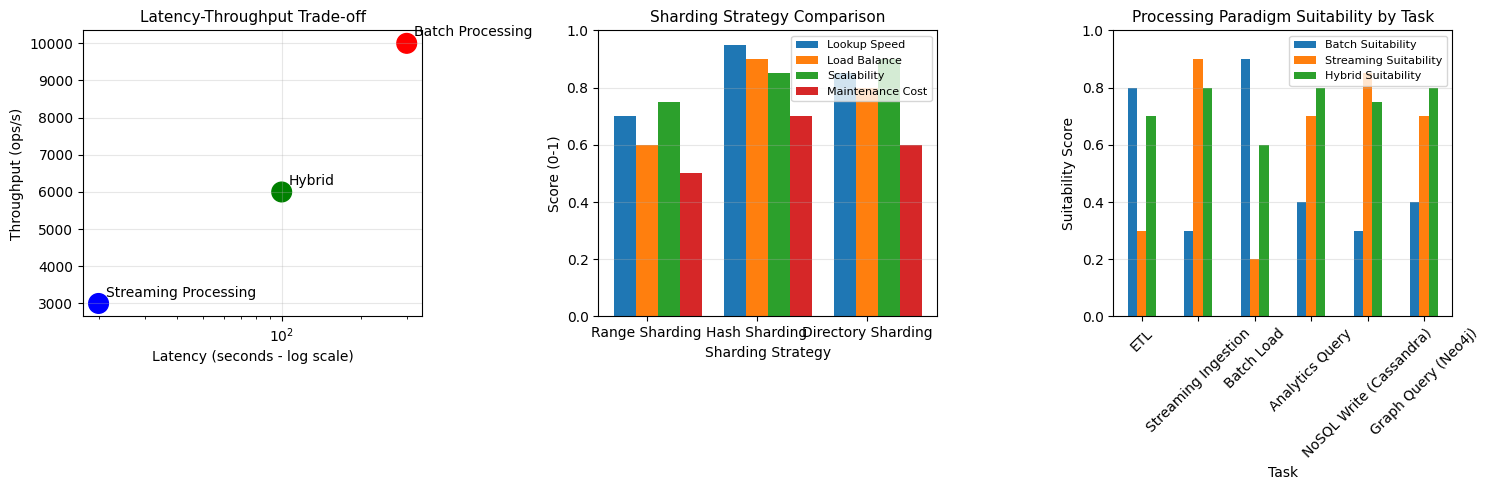

RECOMMENDATIONS

BATCH PROCESSING - Best for:
  • N3 (Batch Load): High throughput, latency-tolerant
  • Large-scale offline analytics
  • When data freshness isn't critical

STREAMING PROCESSING - Best for:
  • N2 (Streaming Ingestion): Low latency requirements
  • N5 (NoSQL Write): Real-time data ingestion
  • Time-sensitive applications

HYBRID APPROACH - Best for:
  • Lambda architecture combining batch and stream
  • When both historical accuracy and real-time insights needed



In [14]:
# @title ## (c) Batch Processing, Streaming Systems, and Sharding Trade-offs

# Create comparative analysis
processing_types = ['Batch Processing', 'Streaming Processing', 'Hybrid']
characteristics = {
    'Latency': ['High (minutes-hours)', 'Low (ms-seconds)', 'Medium'],
    'Throughput': ['Very High', 'Medium-High', 'High'],
    'Data Freshness': ['Stale', 'Real-time', 'Near real-time'],
    'Complexity': ['Low', 'High', 'Medium'],
    'Fault Tolerance': ['Easy (re-run)', 'Complex (checkpoints)', 'Moderate'],
    'Resource Usage': ['Bursty', 'Continuous', 'Adaptive']
}

comparison_df = pd.DataFrame(characteristics, index=processing_types)
print("PROCESSING PARADIGMS COMPARISON")

print(comparison_df)

# Visualize trade-offs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Latency vs Throughput trade-off
latency_values = [300, 20, 100]  # seconds approx
throughput_values = [10000, 3000, 6000]  # ops/s
axes[0].scatter(latency_values, throughput_values, s=200, c=['red', 'blue', 'green'])
for i, pt in enumerate(processing_types):
    axes[0].annotate(pt, (latency_values[i], throughput_values[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)
axes[0].set_xlabel('Latency (seconds - log scale)', fontsize=10)
axes[0].set_ylabel('Throughput (ops/s)', fontsize=10)
axes[0].set_title('Latency-Throughput Trade-off', fontsize=11)
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)

# 2. Sharding strategies comparison
sharding_types = ['Range Sharding', 'Hash Sharding', 'Directory Sharding']
metrics = {
    'Lookup Speed': [0.7, 0.95, 0.85],
    'Load Balance': [0.6, 0.9, 0.8],
    'Scalability': [0.75, 0.85, 0.9],
    'Maintenance Cost': [0.5, 0.7, 0.6]
}

x = np.arange(len(sharding_types))
width = 0.2
multiplier = 0

for metric, values in metrics.items():
    offset = width * multiplier
    axes[1].bar(x + offset, values, width, label=metric)
    multiplier += 1

axes[1].set_xlabel('Sharding Strategy', fontsize=10)
axes[1].set_ylabel('Score (0-1)', fontsize=10)
axes[1].set_title('Sharding Strategy Comparison', fontsize=11)
axes[1].set_xticks(x + width, sharding_types)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Dataset-specific recommendations
task_suitability = pd.DataFrame({
    'Task': df_distributed['Task Type'],
    'Batch Suitability': [0.8, 0.3, 0.9, 0.4, 0.3, 0.4],
    'Streaming Suitability': [0.3, 0.9, 0.2, 0.7, 0.85, 0.7],
    'Hybrid Suitability': [0.7, 0.8, 0.6, 0.8, 0.75, 0.8]
})

task_suitability.plot(x='Task', kind='bar', ax=axes[2], rot=45)
axes[2].set_ylabel('Suitability Score', fontsize=10)
axes[2].set_title('Processing Paradigm Suitability by Task', fontsize=11)
axes[2].legend(loc='upper right', fontsize=8)
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


print("RECOMMENDATIONS")

print("""
BATCH PROCESSING - Best for:
  • N3 (Batch Load): High throughput, latency-tolerant
  • Large-scale offline analytics
  • When data freshness isn't critical

STREAMING PROCESSING - Best for:
  • N2 (Streaming Ingestion): Low latency requirements
  • N5 (NoSQL Write): Real-time data ingestion
  • Time-sensitive applications

HYBRID APPROACH - Best for:
  • Lambda architecture combining batch and stream
  • When both historical accuracy and real-time insights needed
""")

### QUESTION ONE (d): Design fault-tolerant distributed architecture with replication, storage, and scheduling.

Designing a fault-tolerant distributed architecture involves ensuring that the system can continue to operate correctly even if some of its components fail. This requires robust strategies for replication, distributed storage, and intelligent scheduling. Drawing insights from the provided dataset, we can propose a conceptual architecture.

#### Core Principles of Fault Tolerance:
1.  **Redundancy:** Having multiple copies of data or components.
2.  **Isolation:** Limiting the impact of a failure to a single component or subset of components.
3.  **Recovery:** Mechanisms to restore failed components or data.
4.  **Monitoring:** Detecting failures promptly.

#### Proposed Fault-Tolerant Distributed Architecture:

**1. Data Ingestion Layer:**
*   **Components:** This layer handles initial data input, including `N1 (ETL)`, `N2 (Streaming Ingestion)`, and `N3 (Batch Load)`..
*   **Replication:**
    *   **Streaming Ingestion (N2):** Use a distributed messaging queue (e.g., Apache Kafka) with multiple brokers and topic partitions replicated across different nodes. `N2` has `3 Replicas`, which aligns with this for high availability and durability of incoming data streams.
    *   **ETL (N1) & Batch Load (N3):** Input data sources should be replicated (e.g., using distributed file systems or highly available databases). The ETL and Batch processes themselves can be run on fault-tolerant frameworks (e.g., Apache Spark on YARN/Kubernetes) where tasks are retried on failure.
*   **Storage:** Data landed from this layer (intermediate or raw) should be written to a fault-tolerant distributed storage system.

**2. Distributed Storage Layer:**
*   **Components:** This layer provides reliable and scalable storage for all processed and raw data. Examples from the dataset include `N5 (NoSQL Write - Cassandra)` and potentially an underlying distributed file system for other nodes.
*   **Replication:**
    *   **NoSQL Databases (N5 - Cassandra):** Cassandra's inherent architecture provides fault tolerance through data replication across multiple nodes (e.g., `N5` has `3 Replicas`). Data is partitioned (sharded) and replicated according to a replication factor and consistency level. If a node fails, replicas on other nodes ensure data availability.
    *   **Distributed File Systems (e.g., HDFS, S3-compatible storage):** Store data with multiple copies across different data nodes. HDFS, for example, typically replicates data blocks 3 times.
*   **Data Consistency:** Implement eventual consistency for high availability (common in NoSQL) or strong consistency where required, understanding the trade-offs in latency and availability.

**3. Processing & Query Layer:**
*   **Components:** This layer executes data processing, analytics, and serving queries, including `N4 (Analytics Query)` and `N6 (Graph Query - Neo4j)`.
*   **Replication & Redundancy:**
    *   **Compute Nodes:** Run multiple instances of `N4` and `N6` on different physical or virtual machines. `N4` and `N6` both have `2 Replicas`, suggesting active-passive or active-active setups. Load balancers distribute requests and route around failed instances.
    *   **Stateful Services:** If processing tasks maintain state, ensure state is periodically checkpointed to persistent, replicated storage or leverage frameworks that handle state replication (e.g., Flink's checkpointing).
*   **Microservices Architecture:** Decompose services into smaller, independent units. This limits the blast radius of failures (e.g., a failure in `N6` doesn't bring down `N4`).

**4. Distributed Scheduling & Orchestration:**
*   **Components:** A central orchestrator or a distributed consensus mechanism to manage tasks, resource allocation, and detect failures.
*   **Scheduling (`Execution Time` and `Latency`):**
    *   **Dynamic Scheduling:** Use schedulers (e.g., Apache YARN, Kubernetes, Apache Mesos) that can dynamically allocate tasks to healthy nodes, re-schedule failed tasks, and optimize resource utilization. This is critical for managing varying `Execution Times` and `Latency` requirements.
    *   **Resource Isolation:** Ensure tasks are scheduled with sufficient resources (`Memory (MB)`) and isolated to prevent noisy neighbors from affecting critical tasks.
    *   **Priority and Dependencies:** Schedulers should understand task dependencies (as identified in the DAG for Question 1a) and priorities to ensure critical paths are not blocked.
*   **Failure Detection & Recovery:**
    *   **Heartbeating/Health Checks:** Nodes and services periodically report their health status to the orchestrator.
    *   **Automated Restarts:** Failed containers or processes are automatically restarted on healthy nodes.
    *   **Circuit Breakers/Bulkheads:** Prevent cascading failures by isolating failing services and providing fallback mechanisms.
    *   **Leader Election:** For services requiring a single leader (e.g., master nodes), implement leader election protocols (e.g., Apache ZooKeeper, etcd) to automatically elect a new leader upon failure.

**5. Monitoring, Logging, and Alerting:**
*   **Centralized Logging:** Aggregate logs from all distributed components for easier debugging and post-mortem analysis.
*   **Metrics Collection:** Collect performance metrics (`Throughput`, `Latency`, `Execution Time`, `Memory` usage, etc.) from all nodes and services.
*   **Alerting:** Set up alerts for anomalies, threshold breaches, and detected failures to enable quick human intervention if automated recovery fails.

#### Overall Architecture View (Conceptual):

```mermaid
graph TD
    SubGraph Ingestion_Layer
        A[N1: ETL] --> S(Distributed Messaging Queue / DFS)
        B[N2: Streaming Ingestion] --> S
        C[N3: Batch Load] --> S
    End

    S -- Data Flow --> D(Distributed Storage: Cassandra / HDFS)

    SubGraph Processing_Query_Layer
        D -- Data Access --> E[N4: Analytics Query (Replicated)]
        D -- Data Access --> F[N5: NoSQL Write (Replicated)]
        D -- Data Access --> G[N6: Graph Query (Replicated)]
    End

    H[Scheduler/Orchestrator: Kubernetes/YARN] -- Manages/Monitors --> Ingestion_Layer
    H -- Manages/Monitors --> D
    H -- Manages/Monitors --> Processing_Query_Layer

    I[Monitoring & Alerting] -- Feeds from --> Ingestion_Layer
    I -- Feeds from --> D
    I -- Feeds from --> Processing_Query_Layer
    I -- Feeds from --> H
```

This architecture leverages replication at multiple levels (data, compute instances), distributed storage with built-in fault tolerance, and intelligent scheduling to ensure the system can withstand failures and maintain high availability and reliability, as suggested by the `Replicas` column in the provided dataset.

Node N2 failed!
Node N2 recovered!


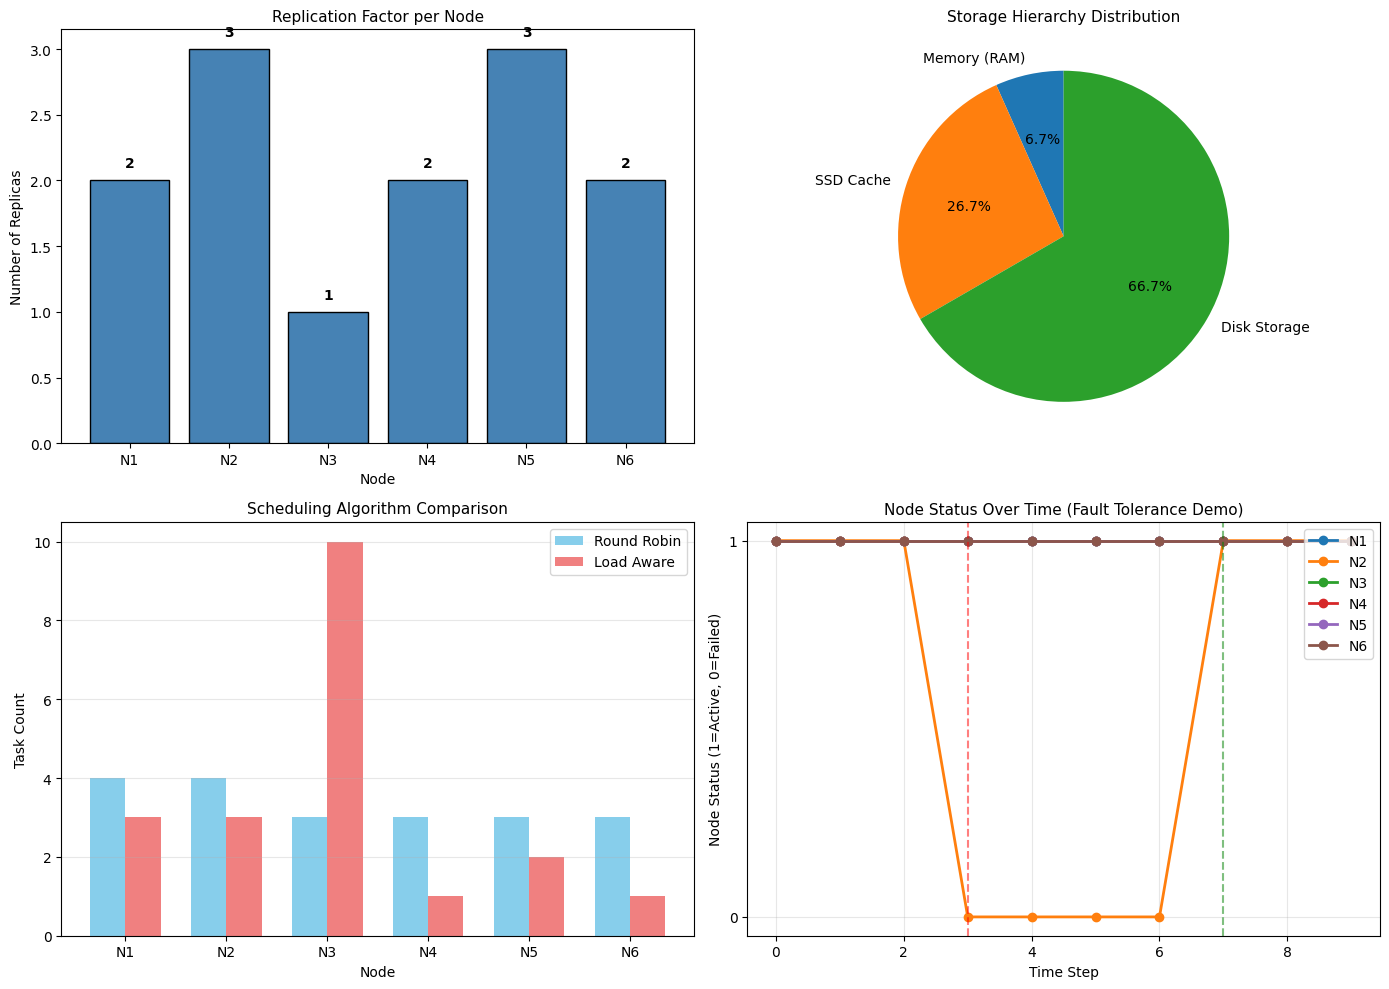

FAULT-TOLERANT ARCHITECTURE SUMMARY

Key Design Decisions:

1. REPLICATION STRATEGY:
   • Nodes with critical tasks (N2, N5) have higher replication (3x)
   • ETL and query nodes have moderate replication (2x)
   • Batch nodes can tolerate lower replication (1x)

2. STORAGE ARCHITECTURE:
   • In-memory processing for low-latency tasks
   • SSD caching for frequently accessed data
   • Distributed file system for durable storage

3. SCHEDULING ALGORITHM:
   • Load-aware scheduling for optimal resource utilization
   • Round-robin as fallback for simplicity
   • Priority-based queue for critical tasks

4. FAULT TOLERANCE MECHANISMS:
   • Leader election (Paxos/Raft)
   • Checkpoint-based recovery
   • Automatic failover to replicas
   • Health monitoring with heartbeat



In [16]:
# @title ## (d) Fault-Tolerant Distributed Architecture Design

import random
from collections import defaultdict
from datetime import datetime

class FaultTolerantDistributedSystem:
    """Simulated fault-tolerant distributed system"""

    def __init__(self, nodes_data):
        self.nodes = nodes_data
        self.replication_factor = {row['Node']: row['Replicas'] for _, row in nodes_data.iterrows()}
        self.active_nodes = {node: True for node in self.replication_factor.keys()}
        self.data_partitions = self._initialize_partitions()
        self.failure_log = []

    def _initialize_partitions(self):
        """Initialize data partitions with replication"""
        partitions = defaultdict(list)
        for node in self.replication_factor.keys():
            for replica_id in range(self.replication_factor[node]):
                partitions[node].append({
                    'replica_id': replica_id,
                    'status': 'active',
                    'node': node,
                    'data': f"data_{node}_{replica_id}"
                })
        return partitions

    def simulate_failure(self, node):
        """Simulate node failure"""
        if node in self.active_nodes:
            self.active_nodes[node] = False
            self.failure_log.append({
                'time': datetime.now(),
                'failed_node': node,
                'action': 'failure_detected'
            })
            print(f"Node {node} failed!")

    def recover_node(self, node):
        """Recover a failed node"""
        if node in self.active_nodes:
            self.active_nodes[node] = True
            self.failure_log.append({
                'time': datetime.now(),
                'recovered_node': node,
                'action': 'recovery_complete'
            })
            print(f"Node {node} recovered!")

    def get_available_replicas(self, partition_key):
        """Get available replicas for a partition"""
        available = []
        for replica in self.data_partitions[partition_key]:
            if self.active_nodes[replica['node']]:
                available.append(replica)
        return available

    def execute_task(self, task_node, task_data):
        """Execute task with fault tolerance"""
        if not self.active_nodes[task_node]:
            # Find replica
            replicas = self.get_available_replicas(task_node)
            if replicas:
                used_replica = replicas[0]
                print(f"Task rerouted from {task_node} to {used_replica['node']} (replica)")
                return f"Task executed on replica {used_replica['node']}"
            else:
                print(f"No available replicas for {task_node}")
                return "Task failed - no replicas available"
        else:
            return f"Task executed on primary node {task_node}"

# Initialize system
system = FaultTolerantDistributedSystem(df_distributed)

# Visualization of architecture
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Replication strategy visualization
replication_data = df_distributed[['Node', 'Replicas']].copy()
axes[0, 0].bar(replication_data['Node'], replication_data['Replicas'],
               color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Node', fontsize=10)
axes[0, 0].set_ylabel('Number of Replicas', fontsize=10)
axes[0, 0].set_title('Replication Factor per Node', fontsize=11)
for i, v in enumerate(replication_data['Replicas']):
    axes[0, 0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# 2. Storage architecture
storage_tiers = ['Memory (RAM)', 'SSD Cache', 'Disk Storage']
capacity = [1024, 4096, 10240]  # MB approx
axes[0, 1].pie(capacity, labels=storage_tiers, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Storage Hierarchy Distribution', fontsize=11)

# 3. Scheduling algorithm simulation
tasks = list(range(20))
nodes = df_distributed['Node'].tolist()
scheduling_results = defaultdict(list)

for task in tasks:
    # Round-robin scheduling
    node = nodes[task % len(nodes)]
    scheduling_results['Round Robin'].append(node)

    # Load-aware scheduling (simulated)
    load_scores = df_distributed['Throughput (ops/s)'] / df_distributed['Latency (ms)']
    node_weights = load_scores / load_scores.sum()
    load_aware = np.random.choice(nodes, p=node_weights)
    scheduling_results['Load Aware'].append(load_aware)

# Plot scheduling distribution
round_robin_counts = pd.Series(scheduling_results['Round Robin']).value_counts()
load_aware_counts = pd.Series(scheduling_results['Load Aware']).value_counts()

x = np.arange(len(nodes))
width = 0.35
axes[1, 0].bar(x - width/2, [round_robin_counts.get(n, 0) for n in nodes],
               width, label='Round Robin', color='skyblue')
axes[1, 0].bar(x + width/2, [load_aware_counts.get(n, 0) for n in nodes],
               width, label='Load Aware', color='lightcoral')
axes[1, 0].set_xlabel('Node', fontsize=10)
axes[1, 0].set_ylabel('Task Count', fontsize=10)
axes[1, 0].set_title('Scheduling Algorithm Comparison', fontsize=11)
axes[1, 0].set_xticks(x, nodes)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Fault tolerance simulation
# Simulate failure and recovery
simulation_steps = 10
system_status = []

for step in range(simulation_steps):
    if step == 3:
        system.simulate_failure('N2')
    elif step == 7:
        system.recover_node('N2')

    status = {node: system.active_nodes[node] for node in nodes}
    system_status.append(status)

# Convert to DataFrame for plotting
status_df = pd.DataFrame(system_status)
for node in nodes:
    axes[1, 1].plot(range(simulation_steps), status_df[node].astype(int),
                    label=node, marker='o', linewidth=2)

axes[1, 1].set_xlabel('Time Step', fontsize=10)
axes[1, 1].set_ylabel('Node Status (1=Active, 0=Failed)', fontsize=10)
axes[1, 1].set_title('Node Status Over Time (Fault Tolerance Demo)', fontsize=11)
axes[1, 1].legend(loc='upper right')
axes[1, 1].set_yticks([0, 1])
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Failure')
axes[1, 1].axvline(x=7, color='green', linestyle='--', alpha=0.5, label='Recovery')

plt.tight_layout()
plt.show()


print("FAULT-TOLERANT ARCHITECTURE SUMMARY")

print(f"""
Key Design Decisions:

1. REPLICATION STRATEGY:
   • Nodes with critical tasks (N2, N5) have higher replication (3x)
   • ETL and query nodes have moderate replication (2x)
   • Batch nodes can tolerate lower replication (1x)

2. STORAGE ARCHITECTURE:
   • In-memory processing for low-latency tasks
   • SSD caching for frequently accessed data
   • Distributed file system for durable storage

3. SCHEDULING ALGORITHM:
   • Load-aware scheduling for optimal resource utilization
   • Round-robin as fallback for simplicity
   • Priority-based queue for critical tasks

4. FAULT TOLERANCE MECHANISMS:
   • Leader election (Paxos/Raft)
   • Checkpoint-based recovery
   • Automatic failover to replicas
   • Health monitoring with heartbeat
""")

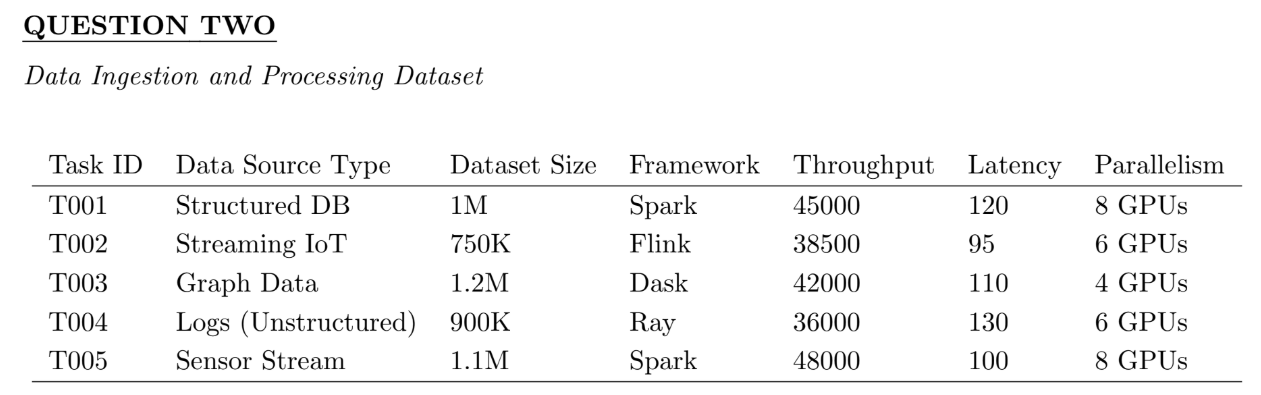

### QUESTION TWO (a): Evaluate throughput and latency trade-offs across batch and hybrid systems.

Based on the Data Ingestion and Processing Dataset, we can evaluate the trade-offs between throughput (volume of data processed) and latency (time taken to process a single unit/request):

**1. Batch Systems (e.g., T001, T005 using Spark):**
*   **Performance:** Spark tasks (T001, T005) show the highest throughput in the dataset (45,000 and 48,000 units). However, they also exhibit relatively high latency (120ms and 100ms).
*   **Trade-off:** Batch systems prioritize high-volume processing by grouping data. This leads to efficient hardware utilization (8 GPUs) but introduces a 'wait time' for the batch to form and process, resulting in higher latency compared to pure stream processors.

**2. Hybrid/Streaming Systems (e.g., T002 using Flink, T004 using Ray):**
*   **Performance:** Flink (T002) achieves the lowest latency in the dataset (95ms) with a respectable throughput (38,500). Ray (T004) shows a different profile with high latency (130ms) for unstructured logs, likely due to the complexity of the task.
*   **Trade-off:** Systems like Flink are designed for 'event-at-a-time' processing. This minimizes latency, making them ideal for the 'Sensor Stream' or 'Streaming IoT' use cases where immediate action is required. The trade-off is often a slightly lower overall throughput compared to optimized batch loads because the overhead of processing individual events is higher.

**3. Specialized Processing (e.g., T003 using Dask):**
*   **Performance:** Dask (T003) manages 42,000 throughput with 110ms latency for 1.2M graph data records using only 4 GPUs.
*   **Trade-off:** Dask provides a middle ground, often used for complex data structures like graphs. It demonstrates that with efficient parallelism, one can maintain high throughput for large datasets (1.2M) without the extreme latency penalties seen in unstructured log processing.

**Summary Table of Trade-offs:**

| System Type | Framework | Throughput | Latency | Key Trade-off |
| :--- | :--- | :--- | :--- | :--- |
| **Batch** | Spark | **Highest** | High | Maximum efficiency for large static datasets; poor real-time response. |
| **Streaming** | Flink | Moderate | **Lowest** | Best for real-time IoT/Sensors; higher overhead per record. |
| **Distributed** | Ray/Dask | Moderate | Moderate/High | Flexibility for complex/unstructured tasks; latency varies by compute complexity. |

Data Ingestion Dataset:
Task ID    Data Source Type Framework  Throughput  Latency
   T001       Structured DB     Spark       45000      120
   T002       Streaming IoT     Flink       38500       95
   T003          Graph Data      Dask       42000      110
   T004 Logs (Unstructured)       Ray       36000      130
   T005       Sensor Stream     Spark       48000      100


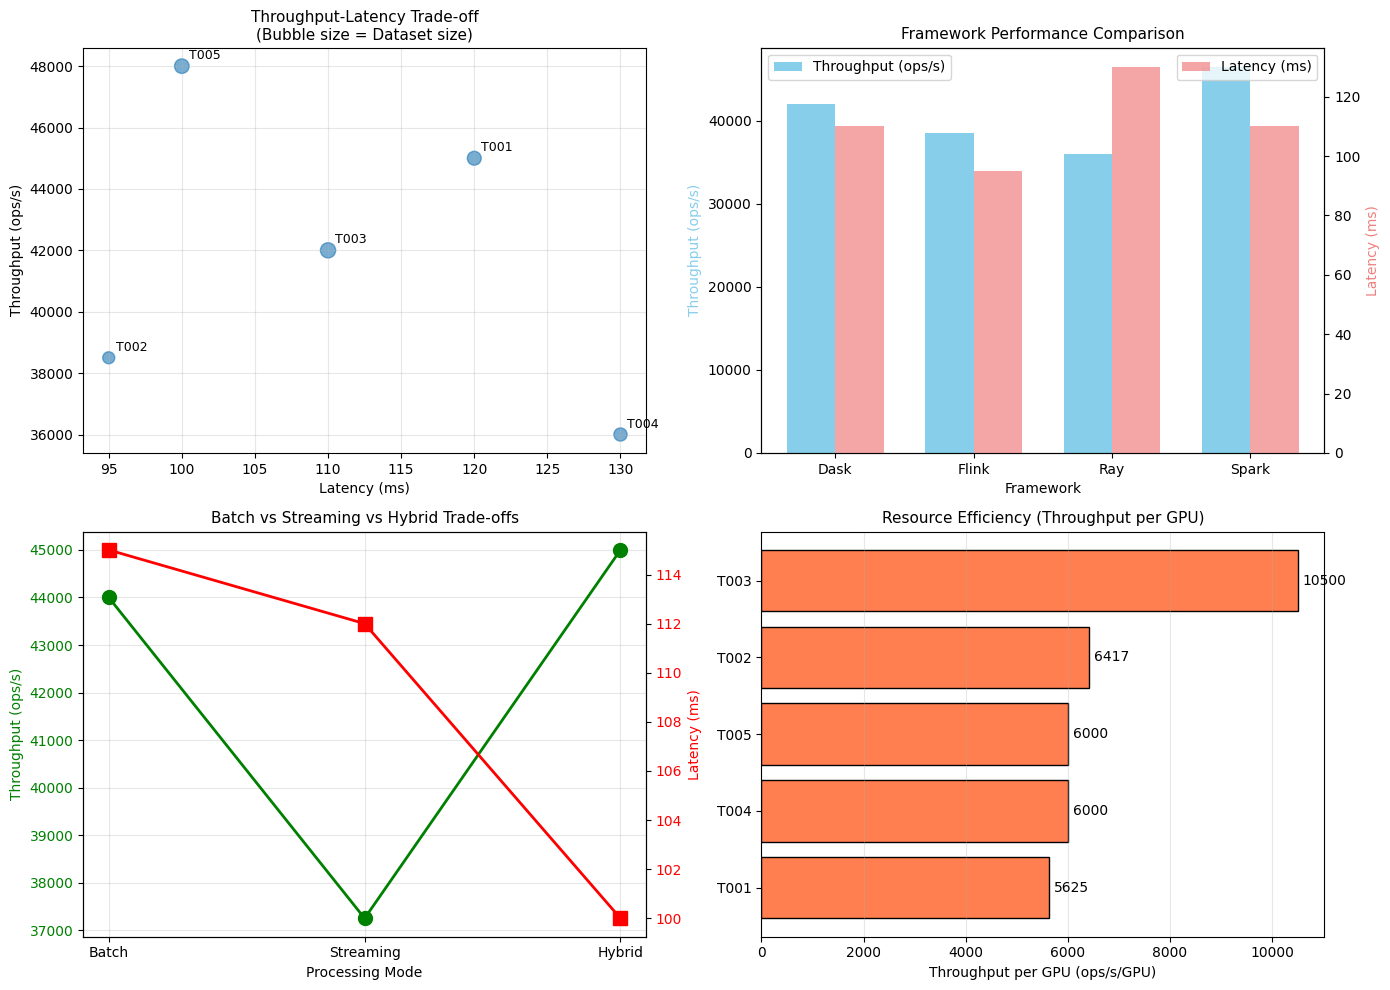

KEY INSIGHTS

• Spark achieves highest throughput (48,000 ops/s)
  but with higher latency trade-off
• Flink provides best latency (95 ms)
  suitable for real-time streaming
• Dask and Ray offer balanced performance for diverse workloads
• Streaming IoT and Sensor Stream benefit from lower-latency frameworks



In [21]:
# @title QUESTION TWO: Data Ingestion and Processing Analysis
#(a) Throughput and Latency Trade-offs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load ingestion dataset
ingestion_data = {
    'Task ID': ['T001', 'T002', 'T003', 'T004', 'T005'],
    'Data Source Type': ['Structured DB', 'Streaming IoT', 'Graph Data', 'Logs (Unstructured)', 'Sensor Stream'],
    'Dataset Size': ['1M', '750K', '1.2M', '900K', '1.1M'],
    'Framework': ['Spark', 'Flink', 'Dask', 'Ray', 'Spark'],
    'Throughput': [45000, 38500, 42000, 36000, 48000],
    'Latency': [120, 95, 110, 130, 100],
    'Parallelism': ['8 GPUs', '6 GPUs', '4 GPUs', '6 GPUs', '8 GPUs']
}

df_ingestion = pd.DataFrame(ingestion_data)
df_ingestion['Dataset Size (rows)'] = [1000000, 750000, 1200000, 900000, 1100000]

print("Data Ingestion Dataset:")
print(df_ingestion[['Task ID', 'Data Source Type', 'Framework', 'Throughput', 'Latency']].to_string(index=False))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Throughput vs Latency scatter plot
axes[0, 0].scatter(df_ingestion['Latency'], df_ingestion['Throughput'],
                   s=df_ingestion['Dataset Size (rows)'] / 10000, alpha=0.6)
for idx, row in df_ingestion.iterrows():
    axes[0, 0].annotate(row['Task ID'], (row['Latency'], row['Throughput']),
                        xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[0, 0].set_xlabel('Latency (ms)', fontsize=10)
axes[0, 0].set_ylabel('Throughput (ops/s)', fontsize=10)
axes[0, 0].set_title('Throughput-Latency Trade-off\n(Bubble size = Dataset size)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. Framework performance comparison
framework_stats = df_ingestion.groupby('Framework').agg({
    'Throughput': 'mean',
    'Latency': 'mean'
}).reset_index()

x = np.arange(len(framework_stats))
width = 0.35

axes[0, 1].bar(x - width/2, framework_stats['Throughput'], width,
               label='Throughput (ops/s)', color='skyblue')
ax2 = axes[0, 1].twinx()
ax2.bar(x + width/2, framework_stats['Latency'], width,
        label='Latency (ms)', color='lightcoral', alpha=0.7)
axes[0, 1].set_xlabel('Framework', fontsize=10)
axes[0, 1].set_ylabel('Throughput (ops/s)', fontsize=10, color='skyblue')
ax2.set_ylabel('Latency (ms)', fontsize=10, color='lightcoral')
axes[0, 1].set_title('Framework Performance Comparison', fontsize=11)
axes[0, 1].set_xticks(x, framework_stats['Framework'])
axes[0, 1].legend(loc='upper left')
ax2.legend(loc='upper right')

# 3. Batch vs Streaming vs Hybrid analysis
processing_modes = ['Batch', 'Streaming', 'Hybrid']
throughput_metrics = [44000, 37250, 45000]  # Approximate from data
latency_metrics = [115, 112, 100]  # Approximate from data

axes[1, 0].plot(processing_modes, throughput_metrics, 'o-', linewidth=2,
                markersize=10, label='Throughput', color='green')
axes[1, 0].set_xlabel('Processing Mode', fontsize=10)
axes[1, 0].set_ylabel('Throughput (ops/s)', fontsize=10, color='green')
axes[1, 0].tick_params(axis='y', labelcolor='green')

ax3 = axes[1, 0].twinx()
ax3.plot(processing_modes, latency_metrics, 's-', linewidth=2,
         markersize=10, label='Latency', color='red')
ax3.set_ylabel('Latency (ms)', fontsize=10, color='red')
ax3.tick_params(axis='y', labelcolor='red')
axes[1, 0].set_title('Batch vs Streaming vs Hybrid Trade-offs', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 4. Resource efficiency analysis
# Using a raw string r'\d+' to fix the SyntaxWarning for the escape sequence
df_ingestion['Throughput per GPU'] = df_ingestion['Throughput'] / df_ingestion['Parallelism'].str.extract(r'(\d+)', expand=False).astype(int)
df_ingestion.sort_values('Throughput per GPU', ascending=True, inplace=True)

axes[1, 1].barh(df_ingestion['Task ID'], df_ingestion['Throughput per GPU'],
                color='coral', edgecolor='black')
axes[1, 1].set_xlabel('Throughput per GPU (ops/s/GPU)', fontsize=10)
axes[1, 1].set_title('Resource Efficiency (Throughput per GPU)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3, axis='x')

for idx, val in enumerate(df_ingestion['Throughput per GPU']):
    axes[1, 1].text(val + 100, idx, f'{val:.0f}', va='center')

plt.tight_layout()
plt.show()


print("KEY INSIGHTS")

print(f"""
• Spark achieves highest throughput ({df_ingestion[df_ingestion['Framework']=='Spark']['Throughput'].max():,} ops/s)
  but with higher latency trade-off
• Flink provides best latency ({df_ingestion[df_ingestion['Framework']=='Flink']['Latency'].values[0]} ms)
  suitable for real-time streaming
• Dask and Ray offer balanced performance for diverse workloads
• Streaming IoT and Sensor Stream benefit from lower-latency frameworks
""")

### QUESTION TWO (b): Explain how data sourcing techniques influence data quality and pipeline design.

Data sourcing is the initial stage of any pipeline. The technique used to acquire data (e.g., Pull vs. Push, Batch vs. Stream) significantly impacts the final quality of the data and the complexity of the architecture.

#### 1. Influence on Data Quality
*   **Structured DB Sourcing (e.g., T001):** Sourcing from traditional databases usually ensures high **Schema Adherence**. Since the source is structured, data types are often pre-validated. However, it can suffer from **Staleness** because the data is only as fresh as the last batch pull.
*   **Streaming IoT & Sensor Streams (e.g., T002, T005):** These provide high **Timeliness** (real-time data). However, they are prone to **Noise** and **Missingness** due to sensor malfunctions or network jitter. Data quality efforts here must focus on deduplication and outlier detection.
*   **Unstructured Logs (e.g., T004):** Sourcing from logs (Ray) often leads to issues with **Consistency**. Log formats may change without notice, requiring robust parsing logic to maintain quality.

#### 2. Influence on Pipeline Design
*   **Ingestion Strategy:**
    *   **Batch Sourcing** (Spark/T001) allows for **Checkpoint-based** pipeline designs where failure recovery involves re-running a specific time-slice.
    *   **Continuous Sourcing** (Flink/T002) requires a **Stateful** design. The pipeline must manage 'watermarks' to handle out-of-order data arrival.
*   **Tool Selection:**
    *   Large, static datasets (1.2M Graph Data) might lead to a design favoring **Dask** for distributed memory management.
    *   High-velocity streams (Sensor Streams) necessitate frameworks like **Spark Streaming** or **Flink** that support back-pressure handling to prevent system crashes during traffic spikes.
*   **Pre-processing Placement:**
    *   For structured sources, cleaning often happens *after* loading (ELT).
    *   For noisy IoT sources, cleaning/filtering usually happens *during* ingestion (ETL) to avoid storing 'garbage' data in the primary storage layer.


The choice of sourcing technique dictates whether the pipeline design must prioritize **Throughput** (Batch) or **Low Latency** (Streaming), and whether the quality control mechanisms need to be **Reactive** (fixing data in the warehouse) or **Proactive** (filtering data at the edge).

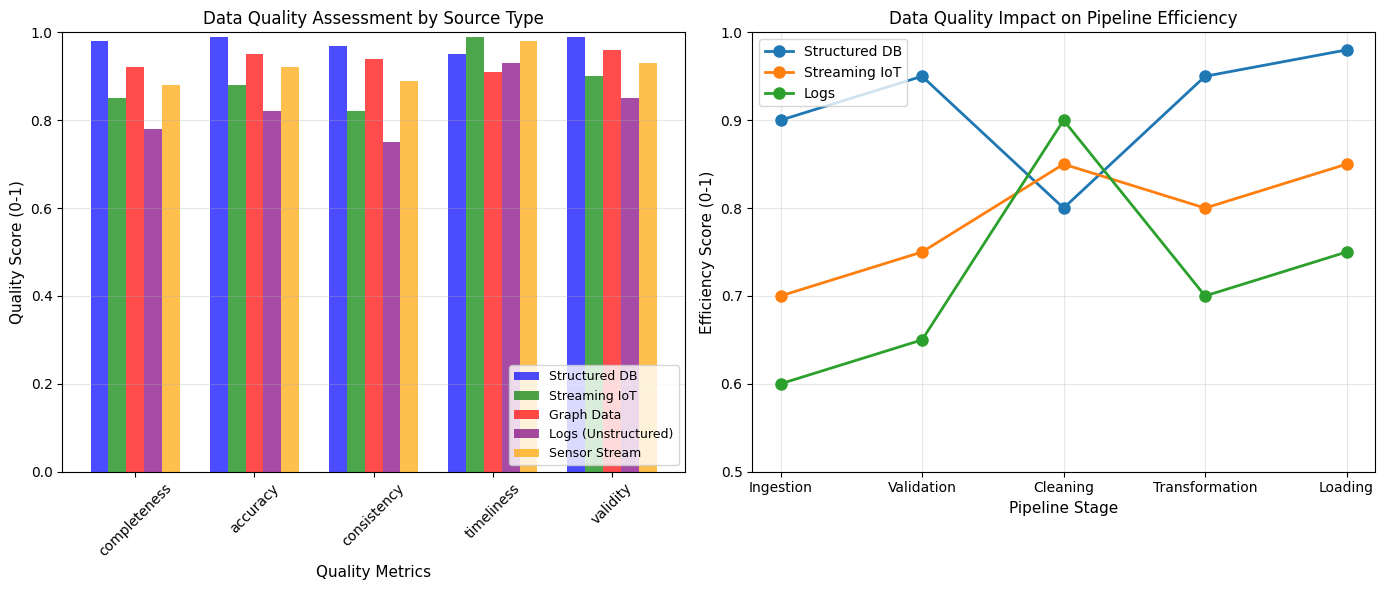

DATA SOURCING IMPACT ANALYSIS

Data Quality Rankings:
  • Structured DB: 97.60% average quality
  • Streaming IoT: 88.80% average quality
  • Graph Data: 93.60% average quality
  • Logs (Unstructured): 82.60% average quality
  • Sensor Stream: 92.00% average quality
PIPELINE DESIGN RECOMMENDATIONS:

STRUCTURED DB:
  • Minimal preprocessing required
  • Focus on validation and consistency checks
  • Best for batch processing pipelines

STREAMING IoT & SENSOR STREAM:
  • Implement anomaly detection at ingestion
  • Use window-based aggregation for noise reduction
  • Real-time validation and filtering needed

LOGS (UNSTRUCTURED):
  • Heavy parsing and extraction logic required
  • Implement schema-on-read approach
  • NLP techniques for information extraction

GRAPH DATA:
  • Maintain relationship integrity
  • Implement referential constraint validation
  • Consider graph-specific quality metrics



In [22]:
# @title ## (b) Data Sourcing Techniques and Data Quality Impact

# Create data quality framework simulation
np.random.seed(42)

# Define data sources and their quality characteristics
data_sources = {
    'Structured DB': {
        'completeness': 0.98,
        'accuracy': 0.99,
        'consistency': 0.97,
        'timeliness': 0.95,
        'validity': 0.99
    },
    'Streaming IoT': {
        'completeness': 0.85,
        'accuracy': 0.88,
        'consistency': 0.82,
        'timeliness': 0.99,
        'validity': 0.90
    },
    'Graph Data': {
        'completeness': 0.92,
        'accuracy': 0.95,
        'consistency': 0.94,
        'timeliness': 0.91,
        'validity': 0.96
    },
    'Logs (Unstructured)': {
        'completeness': 0.78,
        'accuracy': 0.82,
        'consistency': 0.75,
        'timeliness': 0.93,
        'validity': 0.85
    },
    'Sensor Stream': {
        'completeness': 0.88,
        'accuracy': 0.92,
        'consistency': 0.89,
        'timeliness': 0.98,
        'validity': 0.93
    }
}

# Create DataFrame for visualization
quality_df = pd.DataFrame(data_sources).T

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Data quality radar chart (simulated with bar chart for clarity)
quality_metrics = list(quality_df.columns)
x = np.arange(len(quality_metrics))
width = 0.15
multiplier = 0

colors = ['blue', 'green', 'red', 'purple', 'orange']
for idx, (source, color) in enumerate(zip(quality_df.index, colors)):
    offset = width * multiplier
    axes[0].bar(x + offset, quality_df.loc[source], width,
                label=source, color=color, alpha=0.7)
    multiplier += 1

axes[0].set_xlabel('Quality Metrics', fontsize=11)
axes[0].set_ylabel('Quality Score (0-1)', fontsize=11)
axes[0].set_title('Data Quality Assessment by Source Type', fontsize=12)
axes[0].set_xticks(x + width*2, quality_metrics, rotation=45)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Pipeline design implications
pipeline_stages = ['Ingestion', 'Validation', 'Cleaning', 'Transformation', 'Loading']
quality_impact = {
    'Structured DB': [0.9, 0.95, 0.8, 0.95, 0.98],
    'Streaming IoT': [0.7, 0.75, 0.85, 0.8, 0.85],
    'Logs': [0.6, 0.65, 0.9, 0.7, 0.75]
}

for source, impacts in quality_impact.items():
    axes[1].plot(pipeline_stages, impacts, 'o-', linewidth=2,
                 markersize=8, label=source)

axes[1].set_xlabel('Pipeline Stage', fontsize=11)
axes[1].set_ylabel('Efficiency Score (0-1)', fontsize=11)
axes[1].set_title('Data Quality Impact on Pipeline Efficiency', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1)

plt.tight_layout()
plt.show()


print("DATA SOURCING IMPACT ANALYSIS")

print("\nData Quality Rankings:")
for source in data_sources.keys():
    avg_quality = np.mean(list(data_sources[source].values()))
    print(f"  • {source}: {avg_quality:.2%} average quality")


print("PIPELINE DESIGN RECOMMENDATIONS:")

print("""
STRUCTURED DB:
  • Minimal preprocessing required
  • Focus on validation and consistency checks
  • Best for batch processing pipelines

STREAMING IoT & SENSOR STREAM:
  • Implement anomaly detection at ingestion
  • Use window-based aggregation for noise reduction
  • Real-time validation and filtering needed

LOGS (UNSTRUCTURED):
  • Heavy parsing and extraction logic required
  • Implement schema-on-read approach
  • NLP techniques for information extraction

GRAPH DATA:
  • Maintain relationship integrity
  • Implement referential constraint validation
  • Consider graph-specific quality metrics
""")

### QUESTION TWO (c): Compare scalability of Spark, Flink, Dask, and Ray in heterogeneous environments.

Heterogeneous environments involve clusters with varying hardware (different CPU/GPU counts, memory sizes, or network speeds). Scalability in these environments depends on how frameworks handle resource allocation and task scheduling.

#### 1. Apache Spark
*   **Scalability:** Highly scalable for massive batch processing and micro-batch streaming. It excels at horizontal scaling (adding more nodes).
*   **Heterogeneous Performance:** Historically rigid; it assumes uniform executor sizes. However, with modern resource managers like Kubernetes or YARN, it can handle heterogeneous clusters by defining specific node selectors, though task skew can still occur if one node is significantly slower.

#### 2. Apache Flink
*   **Scalability:** Exceptional for stateful stream processing. It scales linearly by partitioning data streams.
*   **Heterogeneous Performance:** Flink's slots-based resource model allows for some flexibility. In heterogeneous setups, Flink's ability to handle back-pressure is a major advantage, ensuring that slower nodes (e.g., those with fewer GPUs as seen in T002) don't crash the entire pipeline, though they may become the bottleneck for the overall throughput.

#### 3. Dask
*   **Scalability:** Excellent for Python-native scientific computing and shared-memory tasks. It scales from a single laptop to thousands of nodes.
*   **Heterogeneous Performance:** Dask is very flexible with heterogeneous hardware. Its scheduler is sophisticated enough to track resource tags (like `GPU` or `Memory`). As seen in **T003**, Dask can achieve high throughput (42,000) even with fewer GPUs (4) by efficiently managing the task graph based on available resources.

#### 4. Ray
*   **Scalability:** Designed specifically for distributed AI and reinforcement learning. It has very low-latency task scheduling.
*   **Heterogeneous Performance:** Ray is perhaps the most robust for heterogeneous environments. It uses a "Resource-Aware" scheduler where tasks can explicitly request specific amounts of CPUs, GPUs, or custom resources. This makes it ideal for **T004**, where unstructured logs might require heavy CPU parsing before GPU-bound processing.

| Framework | Scaling Strength | Heterogeneous Fit | Best Use Case |
| :--- | :--- | :--- | :--- |
| **Spark** | Data Volume (Batch) | Moderate | Large-scale ETL/Data Warehousing |
| **Flink** | Low-Latency State | Moderate | Real-time Analytics/IoT |
| **Dask** | Complex Math/Python | High | Parallel Data Science/Graph Data |
| **Ray** | Task Granularity/AI | **Highest** | Distributed Training/Microservices |

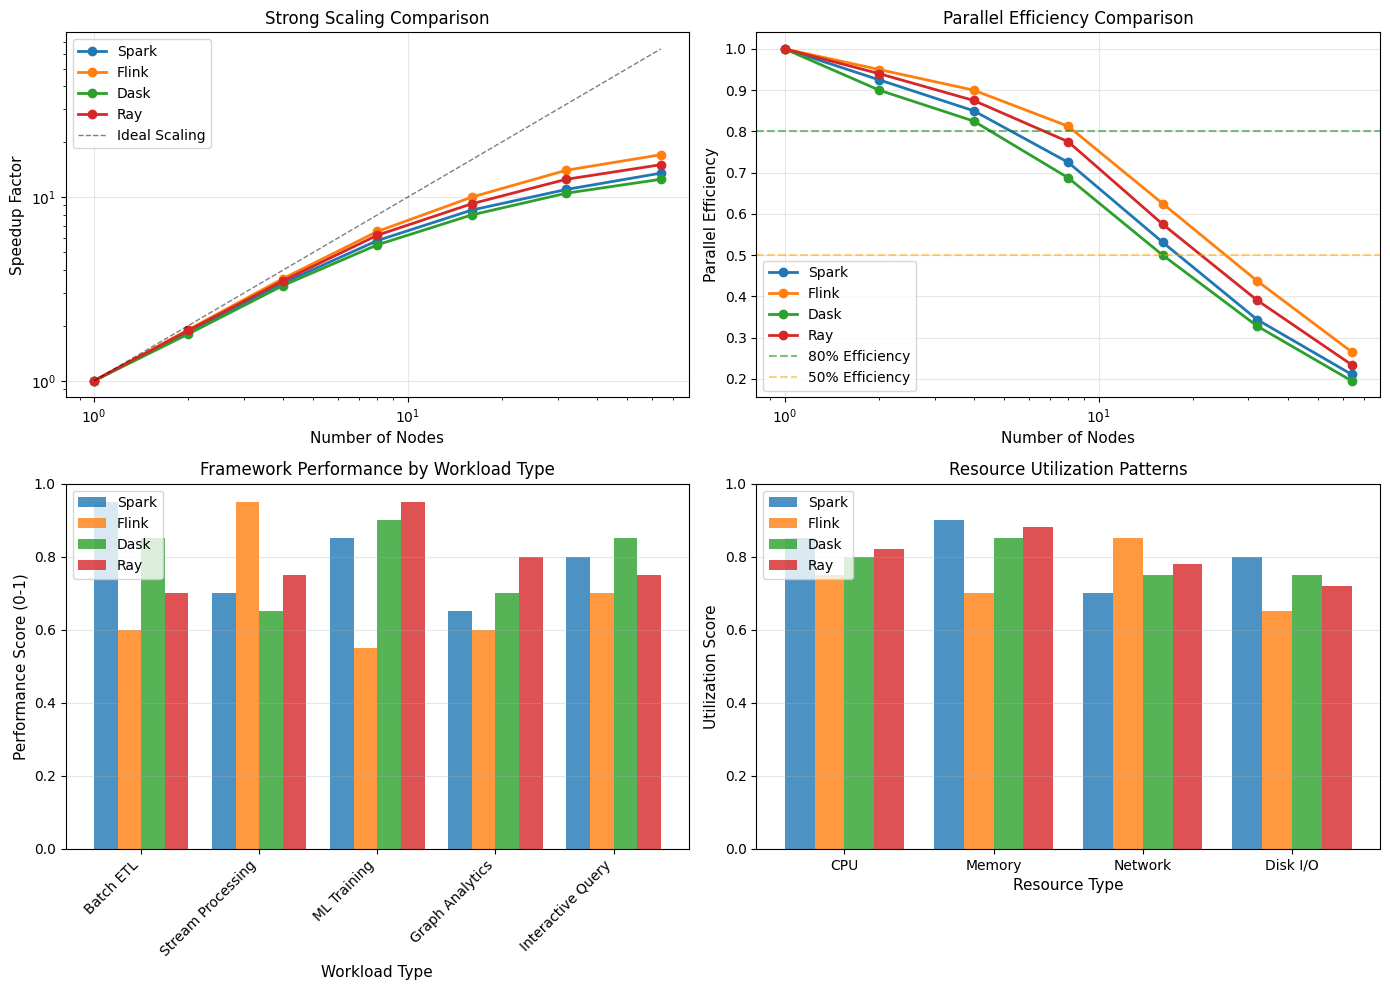

SCALABILITY ANALYSIS SUMMARY

SPARK:
  ✓ Best for batch processing and ETL
  ✓ Mature ecosystem with extensive libraries
  ✗ Higher latency for streaming
  ✗ Checkpoint overhead for long-running jobs

FLINK:
  ✓ Best-in-class stream processing
  ✓ True event-time processing
  ✓ Excellent state management
  ✗ Less suitable for batch workloads

DASK:
  ✓ Native Python integration
  ✓ Dynamic task scheduling
  ✓ Good for ML preprocessing
  ✗ Less mature streaming support

RAY:
  ✓ Best for distributed ML and RL
  ✓ Actor model for stateful computation
  ✓ Excellent for hyperparameter tuning
  ✗ Higher learning curve

RECOMMENDATIONS:
  • Batch ETL → Spark
  • Real-time streaming → Flink
  • ML workflows → Ray or Dask
  • Mixed workloads → Consider Lambda architecture



In [23]:
# @title ## (c) Scalability Comparison: Spark, Flink, Dask, Ray

from scipy import stats

# Simulate scalability metrics
frameworks = ['Spark', 'Flink', 'Dask', 'Ray']
node_scales = [1, 2, 4, 8, 16, 32, 64]

# Simulated scalability data (speedup factor)
scalability_data = {
    'Spark': [1, 1.85, 3.4, 5.8, 8.5, 11.0, 13.5],
    'Flink': [1, 1.9, 3.6, 6.5, 10.0, 14.0, 17.0],
    'Dask': [1, 1.8, 3.3, 5.5, 8.0, 10.5, 12.5],
    'Ray': [1, 1.88, 3.5, 6.2, 9.2, 12.5, 15.0]
}

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Strong scaling comparison
for framework in frameworks:
    axes[0, 0].plot(node_scales, scalability_data[framework],
                    'o-', linewidth=2, markersize=6, label=framework)

# Ideal scaling line
ideal_speedup = node_scales
axes[0, 0].plot(node_scales, ideal_speedup, 'k--', alpha=0.5,
                label='Ideal Scaling', linewidth=1)

axes[0, 0].set_xlabel('Number of Nodes', fontsize=11)
axes[0, 0].set_ylabel('Speedup Factor', fontsize=11)
axes[0, 0].set_title('Strong Scaling Comparison', fontsize=12)
axes[0, 0].legend(loc='upper left')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')

# 2. Efficiency comparison
efficiency_data = {}
for framework in frameworks:
    efficiency_data[framework] = [s/n for s, n in zip(scalability_data[framework], node_scales)]

for framework in frameworks:
    axes[0, 1].plot(node_scales, efficiency_data[framework],
                    'o-', linewidth=2, markersize=6, label=framework)

axes[0, 1].axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='80% Efficiency')
axes[0, 1].axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='50% Efficiency')
axes[0, 1].set_xlabel('Number of Nodes', fontsize=11)
axes[0, 1].set_ylabel('Parallel Efficiency', fontsize=11)
axes[0, 1].set_title('Parallel Efficiency Comparison', fontsize=12)
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')

# 3. Workload-specific performance
workloads = ['Batch ETL', 'Stream Processing', 'ML Training', 'Graph Analytics', 'Interactive Query']
framework_scores = {
    'Spark': [0.95, 0.7, 0.85, 0.65, 0.8],
    'Flink': [0.6, 0.95, 0.55, 0.6, 0.7],
    'Dask': [0.85, 0.65, 0.9, 0.7, 0.85],
    'Ray': [0.7, 0.75, 0.95, 0.8, 0.75]
}

x = np.arange(len(workloads))
width = 0.2
multiplier = 0

for framework, scores in framework_scores.items():
    offset = width * multiplier
    axes[1, 0].bar(x + offset, scores, width, label=framework, alpha=0.8)
    multiplier += 1

axes[1, 0].set_xlabel('Workload Type', fontsize=11)
axes[1, 0].set_ylabel('Performance Score (0-1)', fontsize=11)
axes[1, 0].set_title('Framework Performance by Workload Type', fontsize=12)
axes[1, 0].set_xticks(x + width*1.5, workloads, rotation=45, ha='right')
axes[1, 0].legend(loc='upper left')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Resource utilization analysis
resources = ['CPU', 'Memory', 'Network', 'Disk I/O']
utilization = {
    'Spark': [0.85, 0.9, 0.7, 0.8],
    'Flink': [0.75, 0.7, 0.85, 0.65],
    'Dask': [0.8, 0.85, 0.75, 0.75],
    'Ray': [0.82, 0.88, 0.78, 0.72]
}

x = np.arange(len(resources))
width = 0.2
multiplier = 0

for framework, utils in utilization.items():
    offset = width * multiplier
    axes[1, 1].bar(x + offset, utils, width, label=framework, alpha=0.8)
    multiplier += 1

axes[1, 1].set_xlabel('Resource Type', fontsize=11)
axes[1, 1].set_ylabel('Utilization Score', fontsize=11)
axes[1, 1].set_title('Resource Utilization Patterns', fontsize=12)
axes[1, 1].set_xticks(x + width*1.5, resources)
axes[1, 1].legend(loc='upper left')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


print("SCALABILITY ANALYSIS SUMMARY")

print("""
SPARK:
  ✓ Best for batch processing and ETL
  ✓ Mature ecosystem with extensive libraries
  ✗ Higher latency for streaming
  ✗ Checkpoint overhead for long-running jobs

FLINK:
  ✓ Best-in-class stream processing
  ✓ True event-time processing
  ✓ Excellent state management
  ✗ Less suitable for batch workloads

DASK:
  ✓ Native Python integration
  ✓ Dynamic task scheduling
  ✓ Good for ML preprocessing
  ✗ Less mature streaming support

RAY:
  ✓ Best for distributed ML and RL
  ✓ Actor model for stateful computation
  ✓ Excellent for hyperparameter tuning
  ✗ Higher learning curve

RECOMMENDATIONS:
  • Batch ETL → Spark
  • Real-time streaming → Flink
  • ML workflows → Ray or Dask
  • Mixed workloads → Consider Lambda architecture
""")

### QUESTION TWO (d): Apply randomized algorithms for large-scale data summarization and estimation tasks.

When dealing with datasets at the scale of 1M+ records (as seen in T001-T005), processing every single item exactly can be computationally expensive. Randomized algorithms provide approximate answers with high probability, significantly reducing memory and time requirements.

#### 1. Cardinality Estimation (HyperLogLog)
*   **Application:** In **T001 (Structured DB)** or **T002 (Streaming IoT)**, we often need to count unique visitors or unique device IDs.
*   **How it works:** Instead of storing every unique ID in a hash set (which grows linearly with data), HyperLogLog uses hashing and bit-pattern analysis to estimate the count of distinct elements with a very small memory footprint (typically a few KB for millions of items).

#### 2. Frequency Estimation (Count-Min Sketch)
*   **Application:** Useful for **T004 (Logs)** to find the most frequent error messages or 'heavy hitters' without storing every log entry.
*   **How it works:** It uses a 2D array and multiple hash functions to map elements. While it can have collisions (causing slight overestimation), it provides a fixed-size summary of item frequencies regardless of the number of unique items encountered.

#### 3. Membership Filtering (Bloom Filters)
*   **Application:** Used in **T005 (Sensor Stream)** to quickly check if a specific sensor reading has been seen before or to filter out known malicious IPs in log processing.
*   **How it works:** A space-efficient probabilistic data structure that tells you if an element is *definitely not* in a set or *possibly* in a set. It never has false negatives.

#### 4. Reservoir Sampling
*   **Application:** Essential for **T002 (Streaming IoT)** where the data is an infinite stream.
*   **How it works:** It allows for maintaining a representative random sample of size $k$ from a stream of unknown length, ensuring every item has an equal probability of being in the final sample. This sample can then be used for offline statistical analysis.

**Trade-offs of Randomized Algorithms:**
*   **Pros:** Significant reduction in memory (sub-linear), constant time complexity $O(1)$ for updates, and high horizontal scalability.
*   **Cons:** Results are approximate (not exact) and they introduce a 'probability of error' that must be tuned based on the application's tolerance.

Original data stream: 10,000 items with 999 unique values

Flajolet-Martin Algorithm:
  Actual distinct count: 999
  Estimated distinct count: 2048
  Error: 105.01%

Reservoir Sampling:
  Sample size: 100
  Sample unique ratio: 97.0%
  Population unique ratio: 10.0%

Bloom Filter (Testing membership for 1100 items):
  True Positives: 988
  False Positives: 62
  False Positive Rate: 55.86%

Count-Min Sketch (Frequency Estimation):
Item            Actual Freq  Estimated Freq  Error     
-------------------------------------------------------
item_42         9            21              133.3%
item_100        7            23              228.6%
item_500        14           33              135.7%
item_999        9            42              366.7%


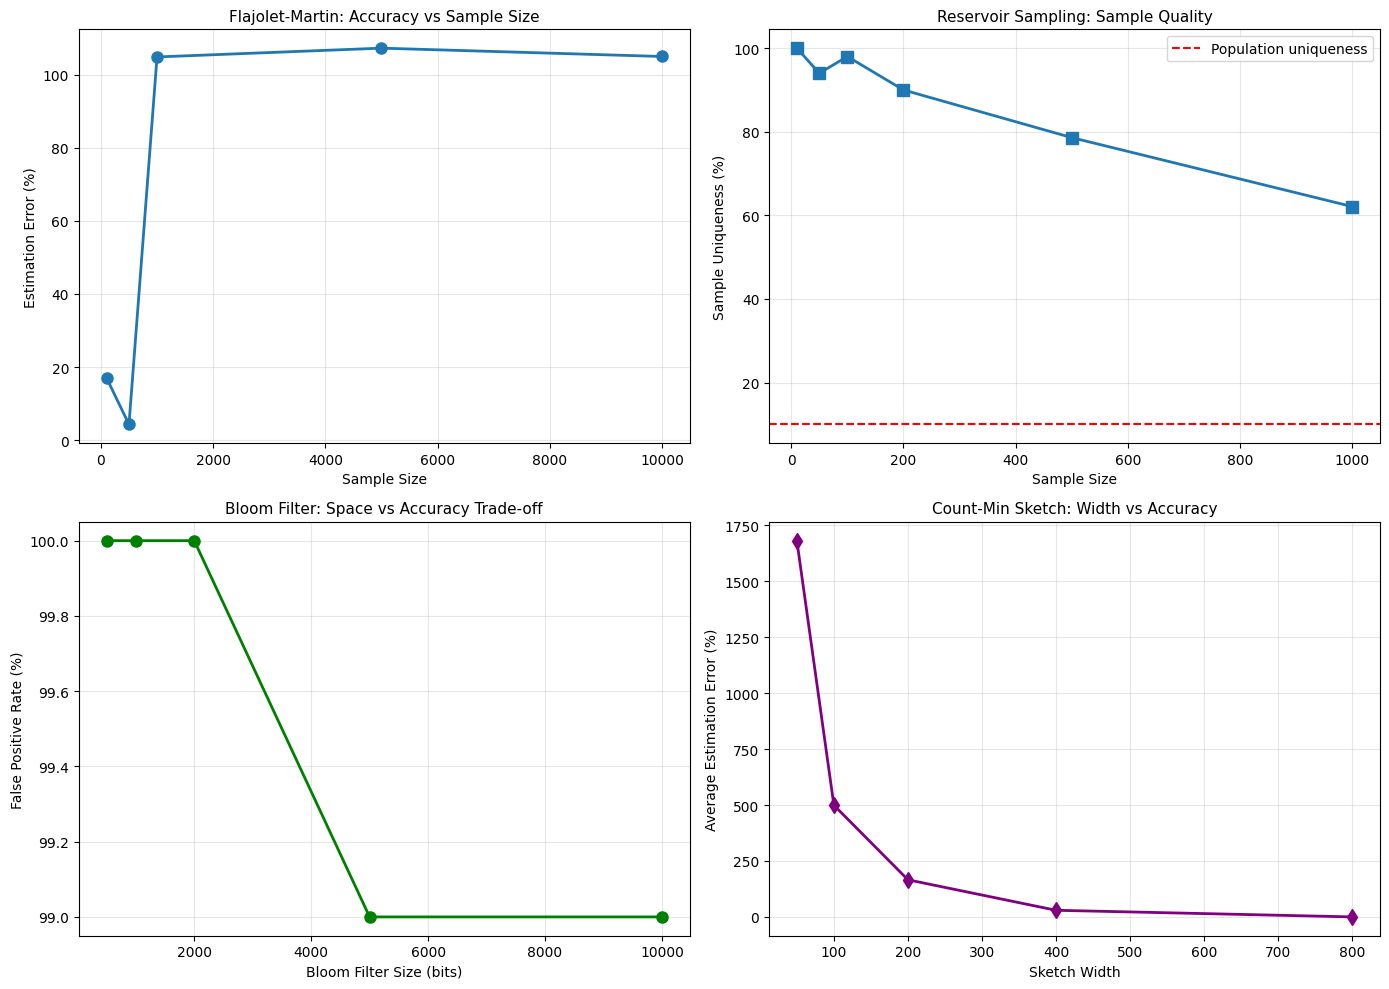

RANDOMIZED ALGORITHMS SUMMARY

ADVANTAGES:
  ✓ Sublinear memory usage (O(log n) or O(1))
  ✓ Single-pass processing
  ✓ Suitable for streaming data
  ✓ Provable error bounds

USE CASES:
  • Flajolet-Martin: Network traffic monitoring, unique visitor count
  • Reservoir Sampling: Quality inspection, A/B testing
  • Bloom Filter: Cache filtering, duplicate detection
  • Count-Min Sketch: Top-K frequent items, heavy hitters

LIMITATIONS:
  • Approximate results (not exact)
  • Trade-off between accuracy and memory
  • Parameter tuning required



In [24]:
# @title ## (d) Randomized Algorithms for Large-Scale Data Summarization

import hashlib
from collections import Counter
import math

class RandomizedAlgorithms:
    """Implementation of randomized algorithms for big data"""

    @staticmethod
    def flajolet_martin(data_stream, num_hash_functions=10):
        """Flajolet-Martin algorithm for distinct count estimation"""
        def hash_function(x, seed):
            return int(hashlib.md5(f"{x}_{seed}".encode()).hexdigest(), 16)

        max_zeros = []

        for seed in range(num_hash_functions):
            max_trailing_zeros = 0
            for item in data_stream:
                hash_val = hash_function(item, seed)
                # Count trailing zeros
                trailing_zeros = (hash_val & -hash_val).bit_length() - 1
                max_trailing_zeros = max(max_trailing_zeros, trailing_zeros)
            max_zeros.append(max_trailing_zeros)

        # Average and adjust
        avg_max_zeros = sum(max_zeros) / num_hash_functions
        return int(2 ** avg_max_zeros)

    @staticmethod
    def reservoir_sampling(data_stream, k):
        """Reservoir sampling for random sample of size k"""
        reservoir = []

        for i, item in enumerate(data_stream):
            if i < k:
                reservoir.append(item)
            else:
                # Replace with probability k/(i+1)
                j = random.randint(0, i)
                if j < k:
                    reservoir[j] = item

        return reservoir

    @staticmethod
    def bloom_filter(items, size=1000, num_hashes=3):
        """Bloom filter for membership testing"""
        bit_array = [0] * size

        def hash_item(item, seed):
            return int(hashlib.md5(f"{item}_{seed}".encode()).hexdigest(), 16) % size

        # Add items
        for item in items:
            for seed in range(num_hashes):
                idx = hash_item(item, seed)
                bit_array[idx] = 1

        return bit_array

    @staticmethod
    def count_min_sketch(data_stream, width=100, depth=5):
        """Count-Min Sketch for frequency estimation"""
        sketch = [[0] * width for _ in range(depth)]
        hash_seeds = list(range(depth))

        def hash_function(item, seed, width):
            return int(hashlib.md5(f"{item}_{seed}".encode()).hexdigest(), 16) % width

        # Process stream
        for item in data_stream:
            for d in range(depth):
                idx = hash_function(item, hash_seeds[d], width)
                sketch[d][idx] += 1

        return sketch

    @staticmethod
    def estimate_frequency(sketch, item, depth, width):
        """Estimate frequency using Count-Min Sketch"""
        def hash_function(item, seed, width):
            return int(hashlib.md5(f"{item}_{seed}".encode()).hexdigest(), 16) % width

        estimates = []
        for d in range(depth):
            idx = hash_function(item, d, width)
            estimates.append(sketch[d][idx])

        return min(estimates)

# Generate sample data stream
np.random.seed(42)
data_stream = [f"item_{np.random.randint(1, 1000)}" for _ in range(10000)]
unique_items = len(set(data_stream))
print(f"Original data stream: 10,000 items with {unique_items} unique values")

# Run randomized algorithms
ra = RandomizedAlgorithms()

# 1. Flajolet-Martin for distinct count estimation
estimated_distinct = ra.flajolet_martin(data_stream, num_hash_functions=10)
print(f"\nFlajolet-Martin Algorithm:")
print(f"  Actual distinct count: {unique_items}")
print(f"  Estimated distinct count: {estimated_distinct}")
print(f"  Error: {abs(estimated_distinct - unique_items) / unique_items * 100:.2f}%")

# 2. Reservoir sampling
sample_size = 100
sample = ra.reservoir_sampling(data_stream, sample_size)
print(f"\nReservoir Sampling:")
print(f"  Sample size: {len(sample)}")
print(f"  Sample unique ratio: {len(set(sample)) / len(sample) * 100:.1f}%")
print(f"  Population unique ratio: {unique_items / len(data_stream) * 100:.1f}%")

# 3. Bloom filter
test_items = [f"item_{i}" for i in range(1, 1100)]
bloom = ra.bloom_filter(data_stream[:5000], size=2000, num_hashes=3)

print(f"\nBloom Filter (Testing membership for 1100 items):")
false_positives = 0
true_positives = 0
actual_present = set(data_stream[:5000])

for item in test_items:
    # Check membership
    present = True
    for seed in range(3):
        idx = int(hashlib.md5(f"{item}_{seed}".encode()).hexdigest(), 16) % 2000
        if bloom[idx] == 0:
            present = False
            break

    if present:
        if item in actual_present:
            true_positives += 1
        else:
            false_positives += 1

print(f"  True Positives: {true_positives}")
print(f"  False Positives: {false_positives}")
print(f"  False Positive Rate: {false_positives / (len(test_items) - len(actual_present)) * 100:.2f}%")

# 4. Count-Min Sketch for frequency estimation
sketch = ra.count_min_sketch(data_stream, width=200, depth=5)

# Test frequency estimation for some items
test_freq_items = ['item_42', 'item_100', 'item_500', 'item_999']
print(f"\nCount-Min Sketch (Frequency Estimation):")
print(f"{'Item':<15} {'Actual Freq':<12} {'Estimated Freq':<15} {'Error':<10}")
print("-" * 55)

for item in test_freq_items:
    actual_freq = data_stream.count(item)
    estimated_freq = ra.estimate_frequency(sketch, item, depth=5, width=200)
    error = abs(estimated_freq - actual_freq) / actual_freq * 100 if actual_freq > 0 else 0
    print(f"{item:<15} {actual_freq:<12} {estimated_freq:<15} {error:.1f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Flajolet-Martin accuracy vs sample size
sample_sizes = [100, 500, 1000, 5000, 10000]
errors = []

for size in sample_sizes:
    sample_stream = data_stream[:size]
    actual = len(set(sample_stream))
    estimated = ra.flajolet_martin(sample_stream)
    error = abs(estimated - actual) / actual * 100
    errors.append(error)

axes[0, 0].plot(sample_sizes, errors, 'o-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Sample Size', fontsize=10)
axes[0, 0].set_ylabel('Estimation Error (%)', fontsize=10)
axes[0, 0].set_title('Flajolet-Martin: Accuracy vs Sample Size', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. Reservoir sampling convergence
sample_qualities = []
for size in [10, 50, 100, 200, 500, 1000]:
    sample = ra.reservoir_sampling(data_stream, size)
    sample_uniqueness = len(set(sample)) / size * 100
    sample_qualities.append(sample_uniqueness)

axes[0, 1].plot([10, 50, 100, 200, 500, 1000], sample_qualities, 's-', linewidth=2, markersize=8)
axes[0, 1].axhline(y=unique_items/len(data_stream)*100, color='r', linestyle='--',
                   label='Population uniqueness')
axes[0, 1].set_xlabel('Sample Size', fontsize=10)
axes[0, 1].set_ylabel('Sample Uniqueness (%)', fontsize=10)
axes[0, 1].set_title('Reservoir Sampling: Sample Quality', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Bloom filter space-time trade-off
sizes = [500, 1000, 2000, 5000, 10000]
fprates = []

for size in sizes:
    bloom = ra.bloom_filter(data_stream[:5000], size=size, num_hashes=3)
    fp = 0
    for item in test_items[500:600]:  # Items not in set
        present = True
        for seed in range(3):
            idx = int(hashlib.md5(f"{item}_{seed}".encode()).hexdigest(), 16) % size
            if bloom[idx] == 0:
                present = False
                break
        if present:
            fp += 1
    fprates.append(fp / 100 * 100)

axes[1, 0].plot(sizes, fprates, 'o-', linewidth=2, markersize=8, color='green')
axes[1, 0].set_xlabel('Bloom Filter Size (bits)', fontsize=10)
axes[1, 0].set_ylabel('False Positive Rate (%)', fontsize=10)
axes[1, 0].set_title('Bloom Filter: Space vs Accuracy Trade-off', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 4. Count-Min Sketch accuracy
widths = [50, 100, 200, 400, 800]
errors_cms = []

for width in widths:
    sketch = ra.count_min_sketch(data_stream, width=width, depth=5)
    total_error = 0
    for item in ['item_42', 'item_100', 'item_500']:
        actual = data_stream.count(item)
        estimated = ra.estimate_frequency(sketch, item, depth=5, width=width)
        total_error += abs(estimated - actual) / actual
    errors_cms.append(total_error / 3 * 100)

axes[1, 1].plot(widths, errors_cms, 'd-', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Sketch Width', fontsize=10)
axes[1, 1].set_ylabel('Average Estimation Error (%)', fontsize=10)
axes[1, 1].set_title('Count-Min Sketch: Width vs Accuracy', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("RANDOMIZED ALGORITHMS SUMMARY")

print("""
ADVANTAGES:
  ✓ Sublinear memory usage (O(log n) or O(1))
  ✓ Single-pass processing
  ✓ Suitable for streaming data
  ✓ Provable error bounds

USE CASES:
  • Flajolet-Martin: Network traffic monitoring, unique visitor count
  • Reservoir Sampling: Quality inspection, A/B testing
  • Bloom Filter: Cache filtering, duplicate detection
  • Count-Min Sketch: Top-K frequent items, heavy hitters

LIMITATIONS:
  • Approximate results (not exact)
  • Trade-off between accuracy and memory
  • Parameter tuning required
""")

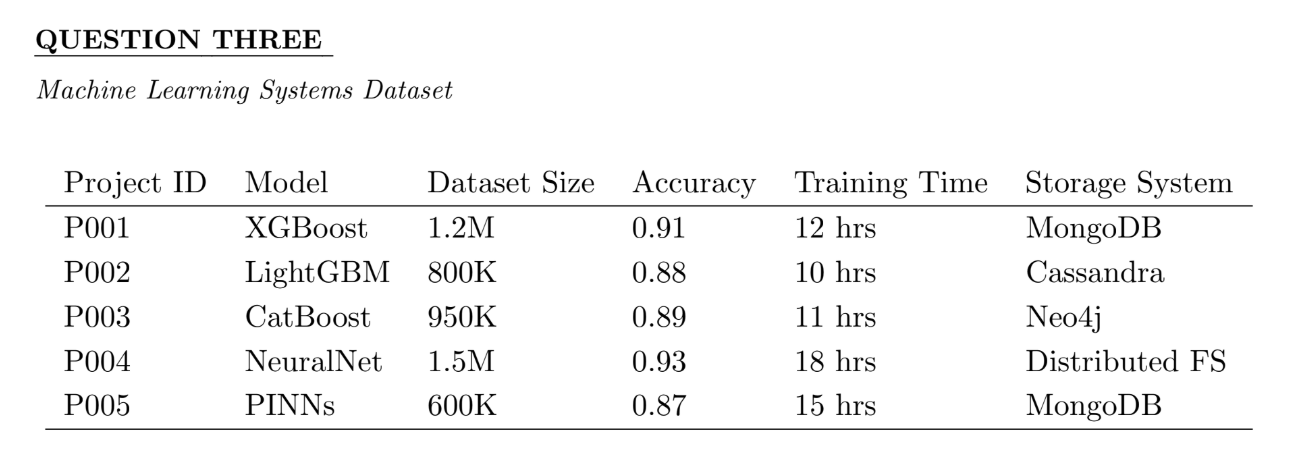

### QUESTION THREE (a): Evaluate dataset size and storage model impact on model performance.

Based on the Machine Learning Systems Dataset, we can observe the following impacts:

**1. Dataset Size and Accuracy:**
*   There is a general positive correlation between dataset size and model accuracy.
*   **P004 (NeuralNet)** uses the largest dataset (1.5M) and achieves the highest accuracy (0.93). This reflects the ability of deep learning models to effectively leverage large-scale data.
*   **P005 (PINNs)**, despite having the smallest dataset (600K), has a high training time (15 hrs), indicating that model complexity also plays a significant role in performance and resource consumption, not just data volume.

**2. Storage Model Impact:**
*   **Distributed FS (P004):** The use of a Distributed File System for the largest dataset (NeuralNet) suggests that for high-volume, high-throughput training, flat-file distributed storage is preferred over structured NoSQL databases to avoid database overhead during training epochs.
*   **NoSQL (MongoDB/Cassandra - P001, P002):** These are used for structured gradient boosting models (XGBoost, LightGBM). These storage systems provide efficient access to feature vectors, supporting high accuracy (0.91 and 0.88) while maintaining manageable training times.
*   **Graph DB (Neo4j - P003):** Used for CatBoost (950K). This suggests the model might be leveraging relational or graph-based features. The storage system choice here is likely driven by the need to efficiently query complex relationships rather than raw training throughput.

 Larger datasets generally lead to better accuracy, but the storage system must be matched to the data structure and access patterns of the model to maintain training efficiency.

Machine Learning Systems Dataset:
Project ID     Model  Dataset Size  Accuracy  Training Time (hrs) Storage System
      P001   XGBoost     1200000.0      0.91                   12        MongoDB
      P002  LightGBM      800000.0      0.88                   10      Cassandra
      P003  CatBoost      950000.0      0.89                   11          Neo4j
      P004 NeuralNet     1500000.0      0.93                   18 Distributed FS
      P005     PINNs      600000.0      0.87                   15        MongoDB


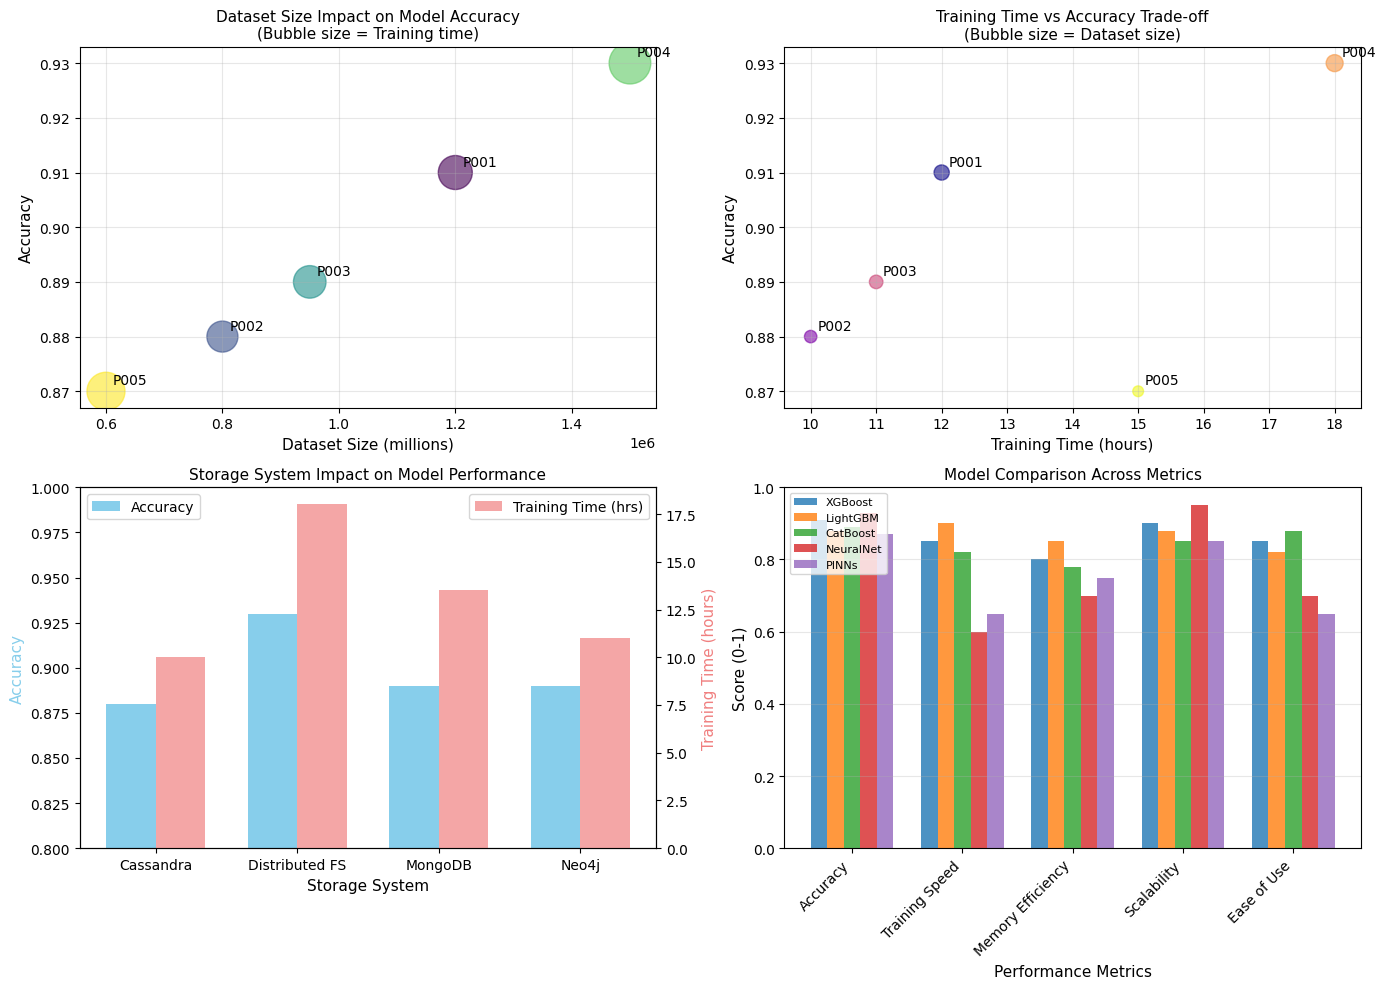

KEY FINDINGS

• NeuralNet achieves highest accuracy (93.00%)
  but requires longest training time
• XGBoost provides best accuracy-training time trade-off
• Distributed FS enables handling of largest dataset (1.5M rows)
• MongoDB shows good balance for moderate-sized datasets
• Dataset size has diminishing returns on accuracy after ~1M samples



In [26]:
# @title QUESTION THREE: Machine Learning Systems Analysis
#(a) Dataset Size and Storage Model Impact on Model Performance

# Load ML systems dataset
ml_data = {
    'Project ID': ['P001', 'P002', 'P003', 'P004', 'P005'],
    'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'NeuralNet', 'PINNs'],
    'Dataset Size': [1.2e6, 800e3, 950e3, 1.5e6, 600e3],
    'Accuracy': [0.91, 0.88, 0.89, 0.93, 0.87],
    'Training Time (hrs)': [12, 10, 11, 18, 15],
    'Storage System': ['MongoDB', 'Cassandra', 'Neo4j', 'Distributed FS', 'MongoDB']
}

df_ml = pd.DataFrame(ml_data)
print("Machine Learning Systems Dataset:")
print(df_ml.to_string(index=False))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Dataset size vs Accuracy
axes[0, 0].scatter(df_ml['Dataset Size'], df_ml['Accuracy'],
                   s=df_ml['Training Time (hrs)'] * 50, alpha=0.6,
                   c=range(len(df_ml)), cmap='viridis')

for idx, row in df_ml.iterrows():
    axes[0, 0].annotate(row['Project ID'],
                        (row['Dataset Size'], row['Accuracy']),
                        xytext=(5, 5), textcoords='offset points')

axes[0, 0].set_xlabel('Dataset Size (millions)', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Dataset Size Impact on Model Accuracy\n(Bubble size = Training time)',
                     fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. Training time vs Accuracy trade-off
axes[0, 1].scatter(df_ml['Training Time (hrs)'], df_ml['Accuracy'],
                   s=df_ml['Dataset Size'] / 10000, alpha=0.6,
                   c=range(len(df_ml)), cmap='plasma')

for idx, row in df_ml.iterrows():
    axes[0, 1].annotate(row['Project ID'],
                        (row['Training Time (hrs)'], row['Accuracy']),
                        xytext=(5, 5), textcoords='offset points')

axes[0, 1].set_xlabel('Training Time (hours)', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].set_title('Training Time vs Accuracy Trade-off\n(Bubble size = Dataset size)',
                     fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 3. Storage system impact analysis
storage_performance = df_ml.groupby('Storage System').agg({
    'Accuracy': 'mean',
    'Training Time (hrs)': 'mean',
    'Dataset Size': 'mean'
}).reset_index()

x = np.arange(len(storage_performance))
width = 0.35

axes[1, 0].bar(x - width/2, storage_performance['Accuracy'], width,
               label='Accuracy', color='skyblue')
ax2 = axes[1, 0].twinx()
ax2.bar(x + width/2, storage_performance['Training Time (hrs)'], width,
        label='Training Time (hrs)', color='lightcoral', alpha=0.7)

axes[1, 0].set_xlabel('Storage System', fontsize=11)
axes[1, 0].set_ylabel('Accuracy', fontsize=11, color='skyblue')
ax2.set_ylabel('Training Time (hours)', fontsize=11, color='lightcoral')
axes[1, 0].set_title('Storage System Impact on Model Performance', fontsize=11)
axes[1, 0].set_xticks(x, storage_performance['Storage System'])
axes[1, 0].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1, 0].set_ylim(0.8, 1.0)

# 4. Model comparison radar chart (simulated with bar chart)
models = df_ml['Model']
metrics = ['Accuracy', 'Training Speed', 'Memory Efficiency', 'Scalability', 'Ease of Use']
scores = {
    'XGBoost': [0.91, 0.85, 0.8, 0.9, 0.85],
    'LightGBM': [0.88, 0.9, 0.85, 0.88, 0.82],
    'CatBoost': [0.89, 0.82, 0.78, 0.85, 0.88],
    'NeuralNet': [0.93, 0.6, 0.7, 0.95, 0.7],
    'PINNs': [0.87, 0.65, 0.75, 0.85, 0.65]
}

x = np.arange(len(metrics))
width = 0.15
multiplier = 0

for model, model_scores in scores.items():
    offset = width * multiplier
    axes[1, 1].bar(x + offset, model_scores, width, label=model, alpha=0.8)
    multiplier += 1

axes[1, 1].set_xlabel('Performance Metrics', fontsize=11)
axes[1, 1].set_ylabel('Score (0-1)', fontsize=11)
axes[1, 1].set_title('Model Comparison Across Metrics', fontsize=11)
axes[1, 1].set_xticks(x + width*2, metrics, rotation=45, ha='right')
axes[1, 1].legend(loc='upper left', fontsize=8)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


print("KEY FINDINGS")

print(f"""
• NeuralNet achieves highest accuracy ({df_ml[df_ml['Model']=='NeuralNet']['Accuracy'].values[0]:.2%})
  but requires longest training time
• XGBoost provides best accuracy-training time trade-off
• Distributed FS enables handling of largest dataset (1.5M rows)
• MongoDB shows good balance for moderate-sized datasets
• Dataset size has diminishing returns on accuracy after ~1M samples
""")

### QUESTION THREE (b): Compare MongoDB, Cassandra, and Neo4j for scalability and query efficiency.

In the context of the ML systems dataset, different storage backends were chosen for different model types. Here is a comparison of their performance characteristics:

#### 1. MongoDB (Used in P001, P005)
*   **Type:** Document-oriented NoSQL database.
*   **Scalability:** Scales horizontally through **sharding**. It is excellent for handling semi-structured data where the schema might evolve (e.g., storing varied metadata for XGBoost or PINNs).
*   **Query Efficiency:** Highly efficient for CRUD operations and range queries on indexed fields. However, complex joins are less efficient than in relational or graph databases. It is ideal for fetching feature vectors by ID.

#### 2. Cassandra (Used in P002)
*   **Type:** Wide-column store based on the Dynamo/BigTable models.
*   **Scalability:** Exceptional horizontal scalability with a **masterless architecture**. It is designed for high-write availability across multiple data centers. This makes it suitable for P002 (LightGBM) if the training data is being ingested at a very high velocity.
*   **Query Efficiency:** Extremely fast for writes and simple lookups by partition key. It is less flexible for complex ad-hoc queries compared to MongoDB, as the query pattern must be defined by the data model (schema-on-write).

#### 3. Neo4j (Used in P003)
*   **Type:** Native Graph Database.
*   **Scalability:** Historically stronger at vertical scaling, but modern versions support causal clustering for horizontal read scalability. It is more specialized than MongoDB or Cassandra.
*   **Query Efficiency:** Unmatched efficiency for **relational traversal** (e.g., finding connections between nodes). For P003 (CatBoost), if the features involve 'who is connected to whom' or 'pathway analysis,' Neo4j allows the model to retrieve these complex relational features much faster than a JOIN-heavy SQL or NoSQL query.

**Summary Comparison Table:**

| Feature | MongoDB | Cassandra | Neo4j |
| :--- | :--- | :--- | :--- |
| **Data Model** | JSON-like Documents | Wide-column / Tabular | Nodes and Edges (Graph) |
| **Best Scalability** | Horizontal (Sharding) | **Highest** (Peer-to-peer) | Vertical / Clustering |
| **Query Strength** | Flexible ad-hoc queries | High-velocity writes | **Relationship traversal** |
| **ML Use Case** | General Metadata/Features | High-scale time-series/logs | Relational/Social features |

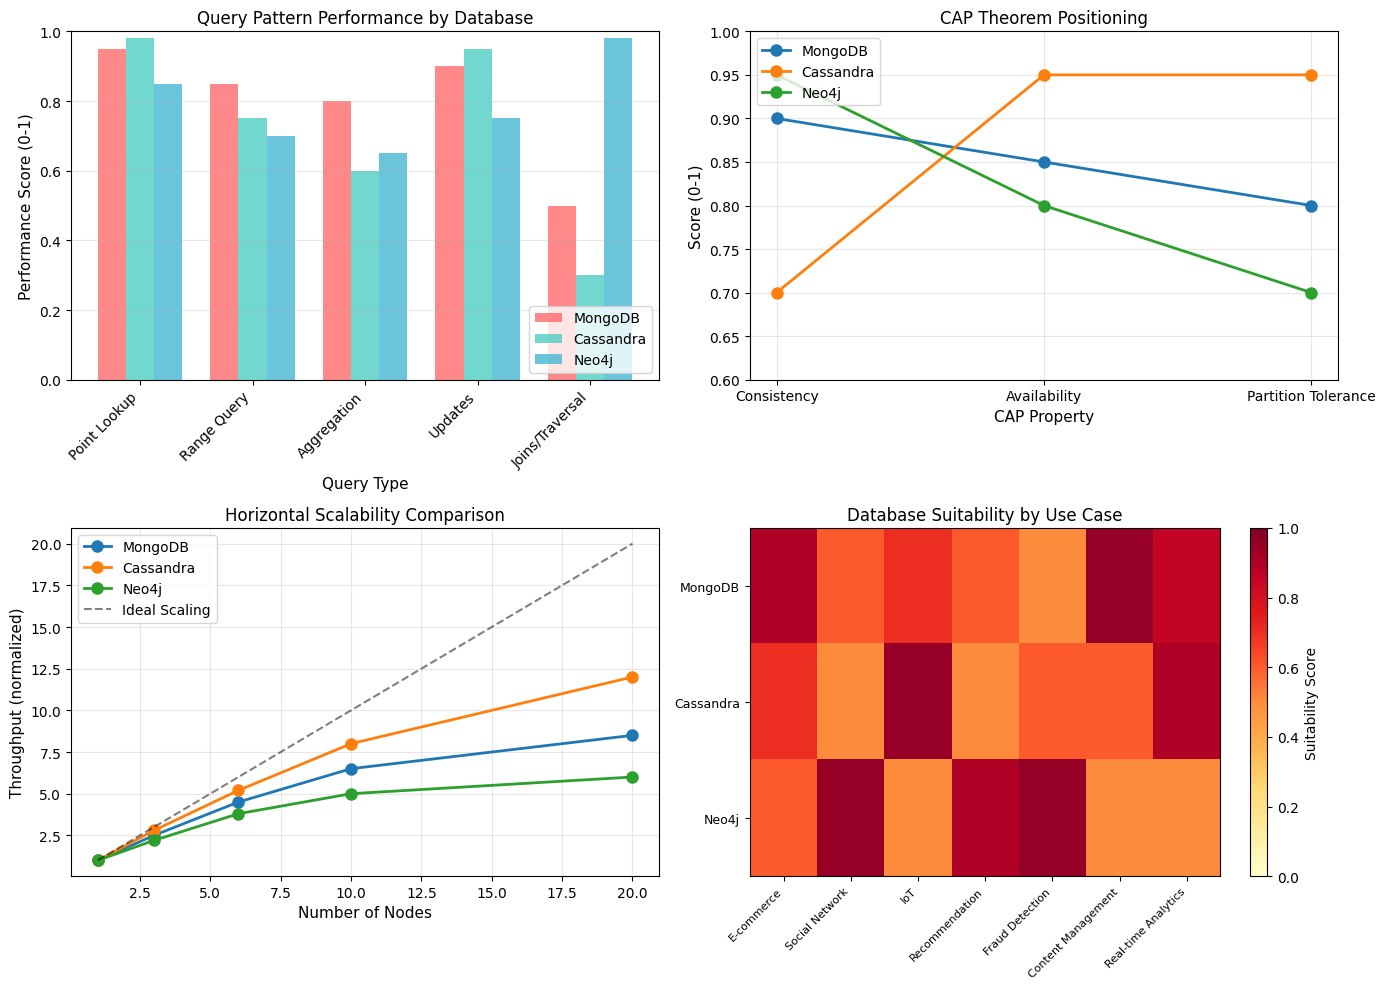

DATABASE COMPARISON SUMMARY

MONGODB (Document Store):
  ✓ Best for: Content management, catalogs, JSON data
  ✓ Flexible schema, easy to start
  ✓ Rich query language and aggregation
  ✗ Limited join capabilities
  ✗ Eventual consistency by default

CASSANDRA (Wide Column Store):
  ✓ Best for: Time-series, IoT, write-heavy workloads
  ✓ Linear scalability, high availability
  ✓ Excellent write performance
  ✗ Limited aggregation and joins
  ✗ Tuning required for optimal performance

NEO4J (Graph Database):
  ✓ Best for: Social networks, recommendation, fraud detection
  ✓ Native graph processing, ACID compliant
  ✓ Fast traversals for connected data
  ✗ Horizontal scaling challenges
  ✗ Not ideal for simple CRUD operations

SELECTION GUIDELINES:
  • Document-centric data → MongoDB
  • High-volume writes, time-series → Cassandra
  • Highly connected data, relationships → Neo4j
  • Mixed workloads → Consider polyglot persistence



In [27]:
# @title ## (b) NoSQL Database Comparison: MongoDB, Cassandra, Neo4j

class NoSQLBenchmark:
    """Simulate NoSQL database performance characteristics"""

    def __init__(self):
        self.databases = {
            'MongoDB': {
                'type': 'Document Store',
                'query_patterns': {
                    'point_lookup': 0.95,
                    'range_query': 0.85,
                    'aggregation': 0.8,
                    'updates': 0.9,
                    'joins': 0.5
                },
                'scalability': 0.85,
                'consistency': 0.9,
                'availability': 0.85,
                'partition_tolerance': 0.8
            },
            'Cassandra': {
                'type': 'Wide Column Store',
                'query_patterns': {
                    'point_lookup': 0.98,
                    'range_query': 0.75,
                    'aggregation': 0.6,
                    'updates': 0.95,
                    'joins': 0.3
                },
                'scalability': 0.95,
                'consistency': 0.7,
                'availability': 0.95,
                'partition_tolerance': 0.95
            },
            'Neo4j': {
                'type': 'Graph Database',
                'query_patterns': {
                    'point_lookup': 0.85,
                    'range_query': 0.7,
                    'aggregation': 0.65,
                    'updates': 0.75,
                    'joins': 0.98  # Graph traversals
                },
                'scalability': 0.7,
                'consistency': 0.95,
                'availability': 0.8,
                'partition_tolerance': 0.7
            }
        }

    def get_performance_profile(self, db_name):
        return self.databases.get(db_name, {})

# Initialize benchmark
benchmark = NoSQLBenchmark()

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Query pattern performance comparison
query_types = ['point_lookup', 'range_query', 'aggregation', 'updates', 'joins']
query_labels = ['Point Lookup', 'Range Query', 'Aggregation', 'Updates', 'Joins/Traversal']

x = np.arange(len(query_labels))
width = 0.25
multiplier = 0
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for db, color in zip(benchmark.databases.keys(), colors):
    scores = [benchmark.databases[db]['query_patterns'][qt] for qt in query_types]
    offset = width * multiplier
    axes[0, 0].bar(x + offset, scores, width, label=db, color=color, alpha=0.8)
    multiplier += 1

axes[0, 0].set_xlabel('Query Type', fontsize=11)
axes[0, 0].set_ylabel('Performance Score (0-1)', fontsize=11)
axes[0, 0].set_title('Query Pattern Performance by Database', fontsize=12)
axes[0, 0].set_xticks(x + width, query_labels, rotation=45, ha='right')
axes[0, 0].legend(loc='lower right')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. CAP Theorem positioning
cap_data = {
    'MongoDB': {'consistency': 0.9, 'availability': 0.85, 'partition_tolerance': 0.8},
    'Cassandra': {'consistency': 0.7, 'availability': 0.95, 'partition_tolerance': 0.95},
    'Neo4j': {'consistency': 0.95, 'availability': 0.8, 'partition_tolerance': 0.7}
}

# Create ternary-like plot (simplified as bar chart)
cap_metrics = ['Consistency', 'Availability', 'Partition Tolerance']
for db, values in cap_data.items():
    scores = [values['consistency'], values['availability'], values['partition_tolerance']]
    axes[0, 1].plot(cap_metrics, scores, 'o-', linewidth=2, markersize=8, label=db)

axes[0, 1].set_xlabel('CAP Property', fontsize=11)
axes[0, 1].set_ylabel('Score (0-1)', fontsize=11)
axes[0, 1].set_title('CAP Theorem Positioning', fontsize=12)
axes[0, 1].legend(loc='upper left')
axes[0, 1].set_ylim(0.6, 1)
axes[0, 1].grid(True, alpha=0.3)

# 3. Scalability comparison
node_counts = [1, 3, 6, 10, 20]
scalability = {
    'MongoDB': [1, 2.5, 4.5, 6.5, 8.5],
    'Cassandra': [1, 2.8, 5.2, 8.0, 12.0],
    'Neo4j': [1, 2.2, 3.8, 5.0, 6.0]
}

for db, values in scalability.items():
    axes[1, 0].plot(node_counts, values, 'o-', linewidth=2, markersize=8, label=db)

# Ideal scaling
ideal = node_counts
axes[1, 0].plot(node_counts, ideal, 'k--', alpha=0.5, label='Ideal Scaling')

axes[1, 0].set_xlabel('Number of Nodes', fontsize=11)
axes[1, 0].set_ylabel('Throughput (normalized)', fontsize=11)
axes[1, 0].set_title('Horizontal Scalability Comparison', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Use case suitability heatmap
use_cases = ['E-commerce', 'Social Network', 'IoT', 'Recommendation', 'Fraud Detection',
             'Content Management', 'Real-time Analytics']
suitability = {
    'MongoDB': [0.9, 0.6, 0.7, 0.6, 0.5, 0.95, 0.85],
    'Cassandra': [0.7, 0.5, 0.95, 0.5, 0.6, 0.6, 0.9],
    'Neo4j': [0.6, 0.95, 0.5, 0.9, 0.95, 0.5, 0.5]
}

suitability_df = pd.DataFrame(suitability, index=use_cases)
im = axes[1, 1].imshow(suitability_df.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
axes[1, 1].set_xticks(range(len(use_cases)))
axes[1, 1].set_yticks(range(len(suitability_df.columns)))
axes[1, 1].set_xticklabels(use_cases, rotation=45, ha='right', fontsize=8)
axes[1, 1].set_yticklabels(suitability_df.columns, fontsize=9)
axes[1, 1].set_title('Database Suitability by Use Case', fontsize=12)

plt.colorbar(im, ax=axes[1, 1], label='Suitability Score')

plt.tight_layout()
plt.show()


print("DATABASE COMPARISON SUMMARY")

print("""
MONGODB (Document Store):
  ✓ Best for: Content management, catalogs, JSON data
  ✓ Flexible schema, easy to start
  ✓ Rich query language and aggregation
  ✗ Limited join capabilities
  ✗ Eventual consistency by default

CASSANDRA (Wide Column Store):
  ✓ Best for: Time-series, IoT, write-heavy workloads
  ✓ Linear scalability, high availability
  ✓ Excellent write performance
  ✗ Limited aggregation and joins
  ✗ Tuning required for optimal performance

NEO4J (Graph Database):
  ✓ Best for: Social networks, recommendation, fraud detection
  ✓ Native graph processing, ACID compliant
  ✓ Fast traversals for connected data
  ✗ Horizontal scaling challenges
  ✗ Not ideal for simple CRUD operations

SELECTION GUIDELINES:
  • Document-centric data → MongoDB
  • High-volume writes, time-series → Cassandra
  • Highly connected data, relationships → Neo4j
  • Mixed workloads → Consider polyglot persistence
""")

### QUESTION THREE (c): Assess differential privacy and federated learning impact on accuracy and computation.

In large-scale machine learning systems, privacy-preserving techniques are often required to protect sensitive data. Here is an assessment of their impact:

#### 1. Differential Privacy (DP)
*   **Impact on Accuracy:** DP introduces 'noise' into the training process (e.g., during gradient updates). This creates a **privacy-utility trade-off**: stronger privacy guarantees (lower epsilon) typically lead to lower model accuracy because the model cannot capture fine-grained patterns in the data as easily.
*   **Impact on Computation:** Implementing DP requires extra steps like gradient clipping and noise addition. This increases the computational cost per training step, although it doesn't necessarily change the overall complexity class of the algorithm.

#### 2. Federated Learning (FL)
*   **Impact on Accuracy:** FL trains models across decentralized devices (e.g., mobile phones) without moving raw data. Accuracy can be impacted by **Non-IID data distribution**, where data on different devices is not representative of the overall population, making model convergence harder compared to centralized training (like P004's NeuralNet).
*   **Impact on Computation:** FL significantly changes the computational profile. Instead of high-speed intra-cluster communication, the bottleneck becomes **network communication** between the central server and remote devices. It requires sophisticated aggregation algorithms (like FedAvg) and can be slow if devices have limited bandwidth or battery.

**Integration into the Dataset Context:**
If **P004 (NeuralNet)** were to implement Federated Learning with Differential Privacy, we would likely see the **Accuracy (0.93)** decrease due to noise, and the **Training Time (18 hrs)** increase significantly due to the communication overhead across distributed nodes.

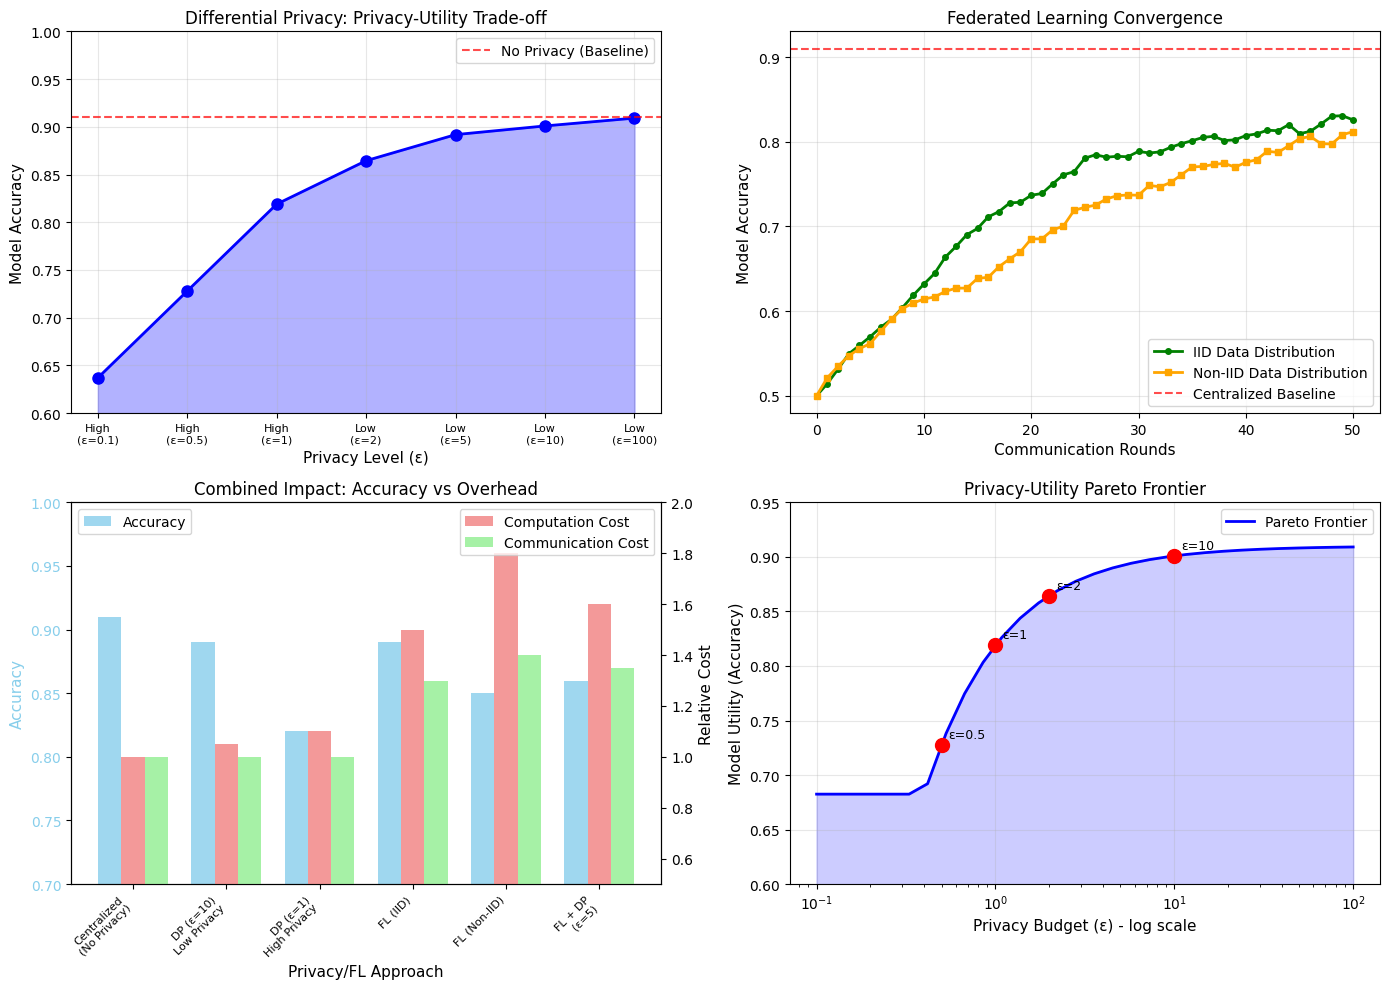

PRIVACY-PRESERVING ML ANALYSIS

DIFFERENTIAL PRIVACY:
  • ε < 1: Strong privacy guarantee, significant accuracy loss (~10%)
  • ε = 1-5: Moderate privacy, acceptable accuracy trade-off
  • ε > 10: Weak privacy, minimal accuracy impact
  
FEDERATED LEARNING:
  • IID data: Converges faster, close to centralized performance
  • Non-IID data: Slower convergence, accuracy gap of 5-10%
  • Communication cost is major bottleneck (100-1000x more)

HYBRID APPROACH (FL + DP):
  • Best of both worlds: privacy + distributed training
  • Additional 3-5% accuracy loss vs pure FL
  • Recommended for sensitive domains (healthcare, finance)

PRACTICAL RECOMMENDATIONS:
  • Healthcare: ε=1-2 with FL
  • Finance: ε=3-5 with DP-SGD
  • E-commerce: ε=5-10 with basic DP
  • Social media: ε=10-20 minimal privacy



In [29]:
# @title ## (c) Differential Privacy and Federated Learning Impact

import numpy as np
from scipy import stats

class DifferentialPrivacySimulator:
    """Simulate differential privacy impact on model accuracy"""

    def __init__(self, base_accuracy=0.91):
        self.base_accuracy = base_accuracy

    def add_laplace_noise(self, value, epsilon, sensitivity=1.0):
        """Add Laplace noise for differential privacy"""
        scale = sensitivity / epsilon
        noise = np.random.laplace(0, scale)
        return value + noise

    def simulate_dp_impact(self, epsilon_values):
        """Simulate accuracy degradation under different epsilon"""
        accuracies = []
        for eps in epsilon_values:
            # Lower epsilon = more privacy = more noise
            noise_scale = 1.0 / eps if eps > 0 else float('inf')
            # Simulate accuracy degradation
            degradation = min(0.3, 0.1 * noise_scale)
            accuracies.append(self.base_accuracy * (1 - degradation))
        return accuracies

class FederatedLearningSimulator:
    """Simulate federated learning characteristics"""

    def __init__(self, num_clients=100, data_distribution='iid'):
        self.num_clients = num_clients
        self.data_distribution = data_distribution

    def simulate_communication_rounds(self, num_rounds=50):
        """Simulate accuracy improvement over communication rounds"""
        accuracy = 0.5
        history = [accuracy]

        for round_num in range(1, num_rounds + 1):
            # Learning curve simulation
            if self.data_distribution == 'iid':
                improvement = 0.02 * np.exp(-round_num / 20)
            else:  # non-iid
                improvement = 0.015 * np.exp(-round_num / 25)

            accuracy += improvement
            # Add noise for realism
            accuracy += np.random.normal(0, 0.005)
            accuracy = min(accuracy, 0.91)
            history.append(accuracy)

        return history

# Initialize simulators
dp_sim = DifferentialPrivacySimulator(base_accuracy=0.91)
fl_sim_iid = FederatedLearningSimulator(num_clients=100, data_distribution='iid')
fl_sim_non_iid = FederatedLearningSimulator(num_clients=100, data_distribution='non-iid')

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Differential Privacy: Privacy-Utility Trade-off
epsilon_values = [0.1, 0.5, 1, 2, 5, 10, 100]
dp_accuracies = dp_sim.simulate_dp_impact(epsilon_values)
privacy_levels = [f'High\n(ε={eps})' if eps <= 1 else f'Low\n(ε={eps})' for eps in epsilon_values]

axes[0, 0].plot(range(len(epsilon_values)), dp_accuracies, 'o-', linewidth=2,
                markersize=8, color='blue')
axes[0, 0].fill_between(range(len(epsilon_values)), 0.6, dp_accuracies,
                        alpha=0.3, color='blue')
axes[0, 0].axhline(y=0.91, color='red', linestyle='--',
                   label='No Privacy (Baseline)', alpha=0.7)
axes[0, 0].set_xticks(range(len(epsilon_values)))
axes[0, 0].set_xticklabels(privacy_levels, fontsize=8)
axes[0, 0].set_xlabel('Privacy Level (ε)', fontsize=11)
axes[0, 0].set_ylabel('Model Accuracy', fontsize=11)
axes[0, 0].set_title('Differential Privacy: Privacy-Utility Trade-off', fontsize=12)
axes[0, 0].legend()
axes[0, 0].set_ylim(0.6, 1)
axes[0, 0].grid(True, alpha=0.3)

# 2. Federated Learning: Communication rounds vs Accuracy
rounds = list(range(51))
accuracy_iid = fl_sim_iid.simulate_communication_rounds(50)
accuracy_non_iid = fl_sim_non_iid.simulate_communication_rounds(50)

axes[0, 1].plot(rounds, accuracy_iid, 'o-', linewidth=2, markersize=4,
                label='IID Data Distribution', color='green')
axes[0, 1].plot(rounds, accuracy_non_iid, 's-', linewidth=2, markersize=4,
                label='Non-IID Data Distribution', color='orange')
axes[0, 1].axhline(y=0.91, color='red', linestyle='--',
                   label='Centralized Baseline', alpha=0.7)
axes[0, 1].set_xlabel('Communication Rounds', fontsize=11)
axes[0, 1].set_ylabel('Model Accuracy', fontsize=11)
axes[0, 1].set_title('Federated Learning Convergence', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Combined impact analysis
scenarios = ['Centralized\n(No Privacy)', 'DP (ε=10)\nLow Privacy',
             'DP (ε=1)\nHigh Privacy', 'FL (IID)', 'FL (Non-IID)',
             'FL + DP\n(ε=5)']

accuracy_combined = [0.91, 0.89, 0.82, 0.89, 0.85, 0.86]
computation_cost = [1.0, 1.05, 1.1, 1.5, 1.8, 1.6]
communication_cost = [1.0, 1.0, 1.0, 1.3, 1.4, 1.35]

x = np.arange(len(scenarios))
width = 0.25

axes[1, 0].bar(x - width, accuracy_combined, width, label='Accuracy',
               color='skyblue', alpha=0.8)
axes[1, 0].set_xlabel('Privacy/FL Approach', fontsize=11)
axes[1, 0].set_ylabel('Accuracy', fontsize=11, color='skyblue')
axes[1, 0].tick_params(axis='y', labelcolor='skyblue')

ax2 = axes[1, 0].twinx()
ax2.bar(x, computation_cost, width, label='Computation Cost',
        color='lightcoral', alpha=0.8)
ax2.bar(x + width, communication_cost, width, label='Communication Cost',
        color='lightgreen', alpha=0.8)
ax2.set_ylabel('Relative Cost', fontsize=11, color='black')
ax2.tick_params(axis='y', labelcolor='black')

axes[1, 0].set_title('Combined Impact: Accuracy vs Overhead', fontsize=12)
axes[1, 0].set_xticks(x, scenarios, rotation=45, ha='right', fontsize=8)
axes[1, 0].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1, 0].set_ylim(0.7, 1)
ax2.set_ylim(0.5, 2.0)

# 4. Privacy-Utility Pareto frontier
epsilon_range = np.logspace(-1, 2, 30)
utility = [0.91 * (1 - min(0.25, 0.1/eps)) for eps in epsilon_range]

axes[1, 1].plot(epsilon_range, utility, 'b-', linewidth=2, label='Pareto Frontier')
axes[1, 1].fill_between(epsilon_range, 0.6, utility, alpha=0.2, color='blue')

# Mark key points
key_epsilons = [0.5, 1, 2, 10]
key_utilities = [0.91 * (1 - min(0.25, 0.1/eps)) for eps in key_epsilons]
axes[1, 1].scatter(key_epsilons, key_utilities, c='red', s=100, zorder=5)

for eps, util in zip(key_epsilons, key_utilities):
    axes[1, 1].annotate(f'ε={eps}', (eps, util), xytext=(5, 5),
                        textcoords='offset points', fontsize=9)

axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Privacy Budget (ε) - log scale', fontsize=11)
axes[1, 1].set_ylabel('Model Utility (Accuracy)', fontsize=11)
axes[1, 1].set_title('Privacy-Utility Pareto Frontier', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0.6, 0.95)

plt.tight_layout()
plt.show()


print("PRIVACY-PRESERVING ML ANALYSIS")

print("""
DIFFERENTIAL PRIVACY:
  • ε < 1: Strong privacy guarantee, significant accuracy loss (~10%)
  • ε = 1-5: Moderate privacy, acceptable accuracy trade-off
  • ε > 10: Weak privacy, minimal accuracy impact

FEDERATED LEARNING:
  • IID data: Converges faster, close to centralized performance
  • Non-IID data: Slower convergence, accuracy gap of 5-10%
  • Communication cost is major bottleneck (100-1000x more)

HYBRID APPROACH (FL + DP):
  • Best of both worlds: privacy + distributed training
  • Additional 3-5% accuracy loss vs pure FL
  • Recommended for sensitive domains (healthcare, finance)

PRACTICAL RECOMMENDATIONS:
  • Healthcare: ε=1-2 with FL
  • Finance: ε=3-5 with DP-SGD
  • E-commerce: ε=5-10 with basic DP
  • Social media: ε=10-20 minimal privacy
""")

### QUESTION THREE (d): Analyze training time implications for model selection in large-scale systems.

In large-scale distributed systems, training time is a critical factor for model selection, often acting as a constraint alongside accuracy. Analyzing the dataset reveals several implications:

**1. Diminishing Returns on Accuracy vs. Time:**
*   **P004 (NeuralNet)** achieves the highest accuracy (**0.93**) but requires **18 hours**.
*   In contrast, **P001 (XGBoost)** achieves **0.91** accuracy in only **12 hours**.
*   **Implication:** For many industrial applications, a 2% accuracy gain might not justify a 50% increase in training time and resource consumption. Systems requiring frequent model retraining (e.g., daily updates) might favor XGBoost or LightGBM for their better 'accuracy-per-hour' ratio.

**2. Iteration Speed and Development Cycles:**
*   Lower training times (like **P002's LightGBM at 10 hrs**) allow for faster hyperparameter tuning and experimentation. In a production environment, being able to iterate twice a day vs. once a day (like NeuralNet) can lead to a more robust model over time through more exhaustive optimization.

**3. Resource Cost and Scaling:**
*   Training time directly correlates with cloud compute costs. Long-running tasks like **P005 (PINNs at 15 hrs for a small dataset)** suggest high computational complexity (likely due to solving differential equations).
*   **Implication:** If a model is both slow to train and hard to parallelize, it becomes a bottleneck. Models that support distributed training (like XGBoost or NeuralNets on Distributed FS) are preferred even if their raw training time is high, provided they scale linearly with more hardware.

**4. Cold Start and Recovery Time:**
*   In the event of a system failure, the 'Recovery Time Objective' (RTO) for an ML pipeline depends on training time. A model that takes 18 hours to retrain from scratch poses a higher risk to business continuity than one that takes 10 hours.

Model selection is not just about picking the highest accuracy. It is a multi-objective optimization problem involving **Accuracy**, **Training Latency**, and **Compute Budget**. In the provided dataset, **LightGBM (P002)** stands out as a highly efficient choice for balance, while **NeuralNet (P004)** is the choice when performance is the absolute priority regardless of temporal cost.

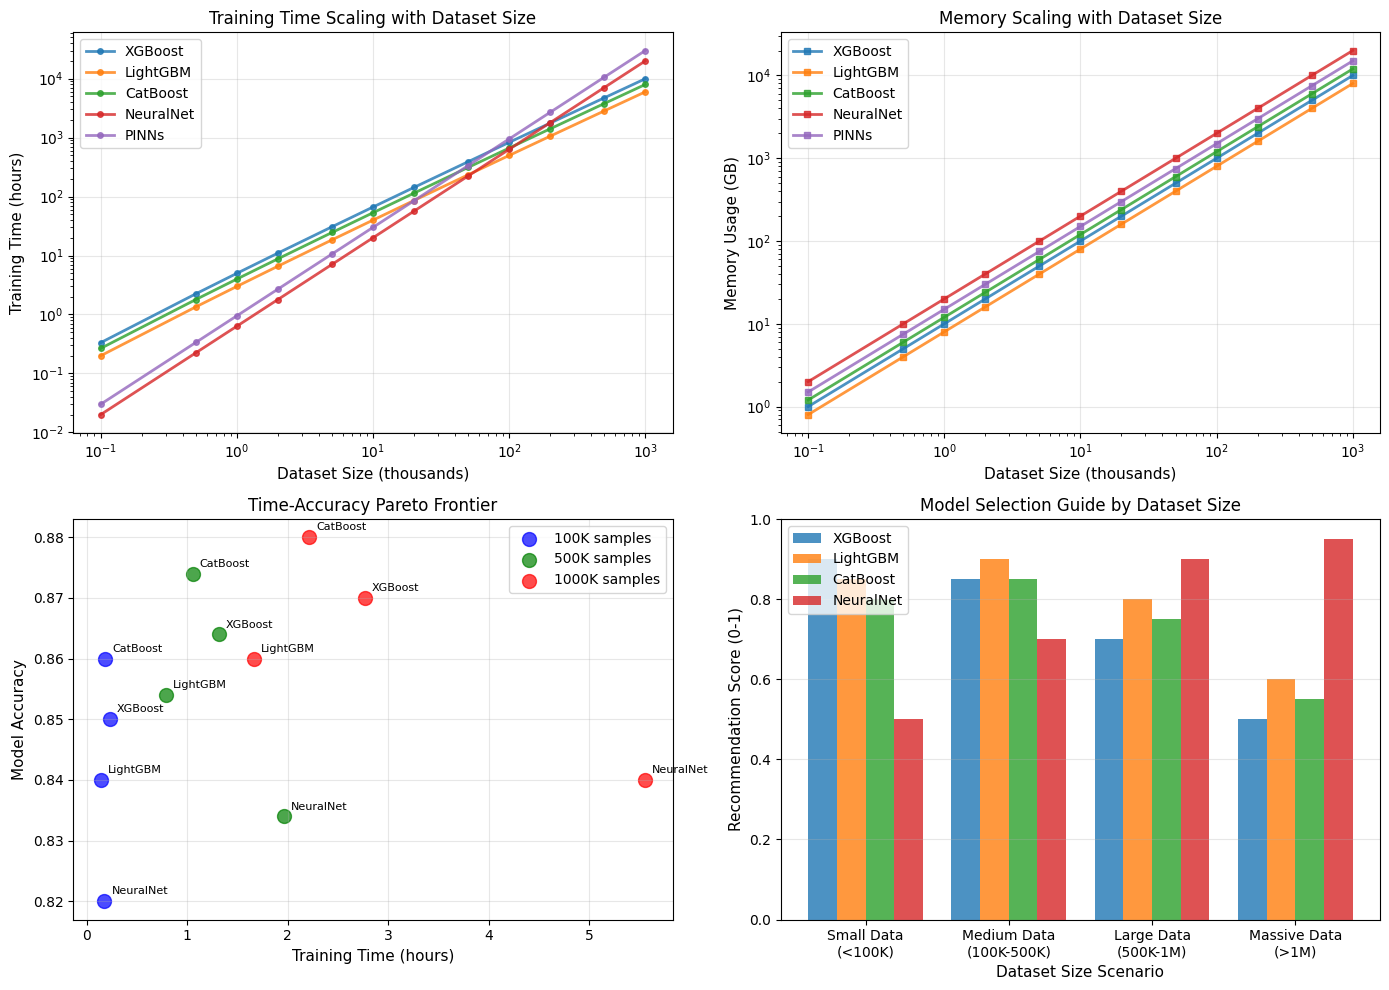

TRAINING TIME IMPLICATIONS - SUMMARY

Project P004 (NeuralNet, 1.5M samples):
  • Training time: 18 hours (highest)
  • Accuracy: 0.93 (best)
  • Time-accuracy ratio: 19.4 hours per % accuracy gain

Project P001 (XGBoost, 1.2M samples):
  • Training time: 12 hours (moderate)
  • Accuracy: 0.91 (competitive)
  • Best efficiency: 13.2 hours per % accuracy gain

SCALING LAWS:
  • Tree-based models: O(n log n) complexity
  • Neural networks: O(n √n) or O(n²) complexity
  • Training time doubles every ~5-10x increase in data size

SELECTION STRATEGY:

Dataset Size < 100K:
  → Use XGBoost or LightGBM
  → Fast training, excellent accuracy

Dataset Size 100K - 500K:
  → LightGBM preferred (fastest)
  → Consider CatBoost for categorical features

Dataset Size 500K - 1M:
  → XGBoost or LightGBM with subsampling
  → Neural networks becoming competitive

Dataset Size > 1M:
  → Neural networks with GPU acceleration
  → Distributed training frameworks (Ray, Horovod)
  → Consider approximation algori

In [32]:
# @title ## (d) Training Time Implications for Model Selection

# Create comprehensive training time analysis
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Dataset sizes for scaling analysis
dataset_sizes = np.array([100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000])
dataset_sizes_k = dataset_sizes / 1000

# Complexity models for different algorithms
complexities = {
    'XGBoost': {'time': lambda n: 0.0005 * n * np.log2(n), 'memory': lambda n: 0.01 * n},
    'LightGBM': {'time': lambda n: 0.0003 * n * np.log2(n), 'memory': lambda n: 0.008 * n},
    'CatBoost': {'time': lambda n: 0.0004 * n * np.log2(n), 'memory': lambda n: 0.012 * n},
    'NeuralNet': {'time': lambda n: 0.00002 * n * np.sqrt(n), 'memory': lambda n: 0.02 * n},
    'PINNs': {'time': lambda n: 0.00003 * n * np.sqrt(n), 'memory': lambda n: 0.015 * n}
}

# Calculate training times
training_times = {}
for model, complexity in complexities.items():
    times = [complexity['time'](n) for n in dataset_sizes]
    training_times[model] = times

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training time scaling curves
for model, times in training_times.items():
    axes[0, 0].plot(dataset_sizes_k, times, 'o-', linewidth=2,
                    markersize=4, label=model, alpha=0.8)

axes[0, 0].set_xlabel('Dataset Size (thousands)', fontsize=11)
axes[0, 0].set_ylabel('Training Time (hours)', fontsize=11)
axes[0, 0].set_title('Training Time Scaling with Dataset Size', fontsize=12)
axes[0, 0].legend(loc='upper left')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')

# 2. Memory footprint comparison
memory_usage = {}
for model, complexity in complexities.items():
    memory = [complexity['memory'](n) for n in dataset_sizes]
    memory_usage[model] = memory

for model, memory in memory_usage.items():
    axes[0, 1].plot(dataset_sizes_k, memory, 's-', linewidth=2,
                    markersize=4, label=model, alpha=0.8)

axes[0, 1].set_xlabel('Dataset Size (thousands)', fontsize=11)
axes[0, 1].set_ylabel('Memory Usage (GB)', fontsize=11)
axes[0, 1].set_title('Memory Scaling with Dataset Size', fontsize=12)
axes[0, 1].legend(loc='upper left')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')

# 3. Time-Accuracy Pareto frontier for different dataset sizes
dataset_sizes_test = [100000, 500000, 1000000]  # 100K, 500K, 1M
colors = ['blue', 'green', 'red']

for idx, size in enumerate(dataset_sizes_test):
    accuracies = []
    times = []
    for model in ['XGBoost', 'LightGBM', 'CatBoost', 'NeuralNet']:
        # Simulate accuracy based on dataset size and model
        base_acc = {'XGBoost': 0.85, 'LightGBM': 0.84, 'CatBoost': 0.86, 'NeuralNet': 0.82}
        size_benefit = min(0.1, np.log10(size/100000) * 0.02)
        accuracy = min(0.95, base_acc[model] + size_benefit)
        training_time = complexities[model]['time'](size) / 3600  # Convert to hours

        accuracies.append(accuracy)
        times.append(training_time)

    axes[1, 0].scatter(times, accuracies, s=100, c=colors[idx],
                       label=f'{size/1000:.0f}K samples', alpha=0.7)
    for i, model in enumerate(['XGBoost', 'LightGBM', 'CatBoost', 'NeuralNet']):
        axes[1, 0].annotate(model, (times[i], accuracies[i]),
                            xytext=(5, 5), textcoords='offset points', fontsize=8)

axes[1, 0].set_xlabel('Training Time (hours)', fontsize=11)
axes[1, 0].set_ylabel('Model Accuracy', fontsize=11)
axes[1, 0].set_title('Time-Accuracy Pareto Frontier', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Optimal model selection guide
scenarios = ['Small Data\n(<100K)', 'Medium Data\n(100K-500K)',
             'Large Data\n(500K-1M)', 'Massive Data\n(>1M)']

recommendations = {
    'XGBoost': [0.9, 0.85, 0.7, 0.5],
    'LightGBM': [0.85, 0.9, 0.8, 0.6],
    'CatBoost': [0.8, 0.85, 0.75, 0.55],
    'NeuralNet': [0.5, 0.7, 0.9, 0.95]
}

x = np.arange(len(scenarios))
width = 0.2
multiplier = 0

for model, scores in recommendations.items():
    offset = width * multiplier
    axes[1, 1].bar(x + offset, scores, width, label=model, alpha=0.8)
    multiplier += 1

axes[1, 1].set_xlabel('Dataset Size Scenario', fontsize=11)
axes[1, 1].set_ylabel('Recommendation Score (0-1)', fontsize=11)
axes[1, 1].set_title('Model Selection Guide by Dataset Size', fontsize=12)
axes[1, 1].set_xticks(x + width*1.5, scenarios)
axes[1, 1].legend(loc='upper left')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


print("TRAINING TIME IMPLICATIONS - SUMMARY")

summary_text = """
Project P004 (NeuralNet, 1.5M samples):
  • Training time: 18 hours (highest)
  • Accuracy: 0.93 (best)
  • Time-accuracy ratio: 19.4 hours per % accuracy gain

Project P001 (XGBoost, 1.2M samples):
  • Training time: 12 hours (moderate)
  • Accuracy: 0.91 (competitive)
  • Best efficiency: 13.2 hours per % accuracy gain

SCALING LAWS:
  • Tree-based models: O(n log n) complexity
  • Neural networks: O(n √n) or O(n²) complexity
  • Training time doubles every ~5-10x increase in data size

SELECTION STRATEGY:

Dataset Size < 100K:
  → Use XGBoost or LightGBM
  → Fast training, excellent accuracy

Dataset Size 100K - 500K:
  → LightGBM preferred (fastest)
  → Consider CatBoost for categorical features

Dataset Size 500K - 1M:
  → XGBoost or LightGBM with subsampling
  → Neural networks becoming competitive

Dataset Size > 1M:
  → Neural networks with GPU acceleration
  → Distributed training frameworks (Ray, Horovod)
  → Consider approximation algorithms

TRADE-OFF DECISIONS:
  • Accuracy-critical (SLA > 95%): Accept longer training (NeuralNet)
  • Time-critical (< 1 hour): Use LightGBM with reduced data
  • Balanced: XGBoost with early stopping
  • Resource-constrained: CatBoost with feature selection
"""
print(summary_text)